# Análisis Exploratorio de Datos (EDA)
## Solución Inteligente de Seguridad Ciudadana para Santander

**Objetivo:** Realizar un análisis exploratorio completo de los datasets de seguridad ciudadana accesibles mediante las APIs de datos.gov.co, enfocado en el departamento de Santander.

**Datasets analizados:**
1. 40 Delitos Bucaramanga (ID: 75fz-q98y) - Municipal
2. 150 Información Delictiva Bucaramanga (ID: x46e-abhz) - Municipal  
3. Reporte Delitos Sexuales Policía Nacional (ID: fpe5-yrmw) - Nacional (filtrado por Santander)
4. Reporte Violencia Intrafamiliar Policía Nacional (ID: vuyt-mqpw) - Nacional (filtrado por Santander)
5. Reporte Hurto por Modalidades Policía Nacional (ID: d4fr-sbn2) - Nacional (filtrado por Santander)

**Fecha de análisis:** Noviembre 17, 2025

## 1. Configuración Inicial e Importación de Librerías

In [7]:
# Importar librerías necesarias
import pandas as pd
import numpy as np
import requests
import json
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
from dotenv import load_dotenv
import os

# Configuración de visualización
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', None)

# Cargar variables de entorno
load_dotenv()
APP_TOKEN = os.getenv('AppToken')

print("✅ Librerías importadas exitosamente")
print(f"✅ AppToken cargado: {'Sí' if APP_TOKEN else 'No'}")

✅ Librerías importadas exitosamente
✅ AppToken cargado: Sí


## 2. Configuración de APIs y Funciones de Extracción de Datos

In [8]:
# Configuración de datasets
DATASETS = {
    'delitos_bucaramanga': {
        'id': '75fz-q98y',
        'name': '40 Delitos Bucaramanga',
        'scope': 'municipal',
        'filter': None,  # Ya es específico de Bucaramanga
        'url': 'https://www.datos.gov.co/resource/75fz-q98y.json'
    },
    'info_delictiva_bucaramanga': {
        'id': 'x46e-abhz',
        'name': '150 Información Delictiva Bucaramanga',
        'scope': 'municipal',
        'filter': None,  # Ya es específico de Bucaramanga
        'url': 'https://www.datos.gov.co/resource/x46e-abhz.json'
    },
    'delitos_sexuales': {
        'id': 'fpe5-yrmw',
        'name': 'Delitos Sexuales Nacional',
        'scope': 'nacional',
        'filter': "departamento='SANTANDER'",
        'url': 'https://www.datos.gov.co/resource/fpe5-yrmw.json'
    },
    'violencia_intrafamiliar': {
        'id': 'vuyt-mqpw',
        'name': 'Violencia Intrafamiliar Nacional',
        'scope': 'nacional',
        'filter': "departamento='SANTANDER'",
        'url': 'https://www.datos.gov.co/resource/vuyt-mqpw.json'
    },
    'hurto_modalidades': {
        'id': 'd4fr-sbn2',
        'name': 'Hurto por Modalidades Nacional',
        'scope': 'nacional',
        'filter': "departamento='SANTANDER'",
        'url': 'https://www.datos.gov.co/resource/d4fr-sbn2.json'
    }
}

print("✅ Configuración de datasets completada")
print(f"Total de datasets a analizar: {len(DATASETS)}")

✅ Configuración de datasets completada
Total de datasets a analizar: 5


In [9]:
def fetch_soda_data(url, where_clause=None, limit=50000, app_token=None, max_records=None):
    """
    Extrae datos de la API SODA con paginación automática.
    
    Parámetros:
    - url: URL del endpoint de la API
    - where_clause: Cláusula WHERE para filtrar datos (e.g., "departamento='SANTANDER'")
    - limit: Número de registros por solicitud (máximo 50000)
    - app_token: Token de aplicación para autenticación
    - max_records: Número máximo de registros a extraer (None = todos)
    
    Retorna:
    - DataFrame de pandas con los datos
    """
    all_data = []
    offset = 0
    headers = {}
    
    if app_token:
        headers['X-App-Token'] = app_token
    
    print(f"Extrayendo datos de: {url}")
    if where_clause:
        print(f"Filtro aplicado: {where_clause}")
    
    while True:
        # Configurar parámetros de la solicitud
        params = {
            '$limit': limit,
            '$offset': offset,
            '$order': ':id'  # Ordenar por ID para consistencia
        }
        
        if where_clause:
            params['$where'] = where_clause
        
        try:
            # Realizar solicitud HTTP
            response = requests.get(url, params=params, headers=headers, timeout=30)
            response.raise_for_status()
            
            # Parsear respuesta JSON
            batch = response.json()
            
            if not batch:
                break
            
            all_data.extend(batch)
            offset += limit
            
            print(f"  Registros extraídos: {len(all_data)}", end='\r')
            
            # Detener si alcanzamos el máximo de registros
            if max_records and len(all_data) >= max_records:
                all_data = all_data[:max_records]
                break
            
            # Detener si recibimos menos registros que el límite (última página)
            if len(batch) < limit:
                break
                
        except requests.exceptions.RequestException as e:
            print(f"\n❌ Error en la solicitud: {e}")
            break
    
    print(f"\n✅ Total de registros extraídos: {len(all_data)}")
    
    # Convertir a DataFrame
    df = pd.DataFrame(all_data)
    return df


# Función auxiliar para obtener metadatos
def get_dataset_metadata(df, dataset_name):
    """
    Extrae metadatos básicos de un DataFrame.
    """
    metadata = {
        'nombre': dataset_name,
        'registros': len(df),
        'columnas': len(df.columns),
        'memoria_mb': df.memory_usage(deep=True).sum() / 1024**2,
        'columnas_list': list(df.columns)
    }
    return metadata

print("✅ Funciones de extracción definidas")

✅ Funciones de extracción definidas


## 3. Extracción de Datos de los 5 Datasets

In [10]:
# Extraer datos de todos los datasets
dataframes = {}
metadata_list = []

for key, config in DATASETS.items():
    print(f"\n{'='*80}")
    print(f"Extrayendo: {config['name']}")
    print(f"Alcance: {config['scope']}")
    print('='*80)
    
    df = fetch_soda_data(
        url=config['url'],
        where_clause=config['filter'],
        app_token=APP_TOKEN
    )
    
    dataframes[key] = df
    metadata = get_dataset_metadata(df, config['name'])
    metadata_list.append(metadata)
    
    print(f"Dimensiones: {df.shape[0]} filas × {df.shape[1]} columnas")
    print(f"Memoria: {metadata['memoria_mb']:.2f} MB\n")

print("\n" + "="*80)
print("✅ EXTRACCIÓN COMPLETADA")
print("="*80)


Extrayendo: 40 Delitos Bucaramanga
Alcance: municipal
Extrayendo datos de: https://www.datos.gov.co/resource/75fz-q98y.json
  Registros extraídos: 135076
✅ Total de registros extraídos: 135076
Dimensiones: 135076 filas × 19 columnas
Memoria: 152.65 MB


Extrayendo: 150 Información Delictiva Bucaramanga
Alcance: municipal
Extrayendo datos de: https://www.datos.gov.co/resource/x46e-abhz.json
  Registros extraídos: 120940
✅ Total de registros extraídos: 120940
Dimensiones: 120940 filas × 26 columnas
Memoria: 182.49 MB


Extrayendo: Delitos Sexuales Nacional
Alcance: nacional
Extrayendo datos de: https://www.datos.gov.co/resource/fpe5-yrmw.json
Filtro aplicado: departamento='SANTANDER'
  Registros extraídos: 21859
✅ Total de registros extraídos: 21859
Dimensiones: 21859 filas × 9 columnas
Memoria: 12.21 MB


Extrayendo: Violencia Intrafamiliar Nacional
Alcance: nacional
Extrayendo datos de: https://www.datos.gov.co/resource/vuyt-mqpw.json
Filtro aplicado: departamento='SANTANDER'
  Regist

In [11]:
# Resumen de metadatos de todos los datasets
metadata_df = pd.DataFrame(metadata_list)
print("\n📊 RESUMEN DE DATASETS EXTRAÍDOS\n")
print(metadata_df.to_string(index=False))
print(f"\n📦 Total de registros extraídos: {metadata_df['registros'].sum():,}")


📊 RESUMEN DE DATASETS EXTRAÍDOS

                               nombre  registros  columnas  memoria_mb                                                                                                                                                                                                                                                                                                                                 columnas_list
               40 Delitos Bucaramanga     135076        19  152.653170                                                                                                       [orden, armas_medios, barrios_hecho, latitud, longitud, zona, nom_comuna, ano, mes, dia, dia_semana, descripcion_conducta, conducta, clasificaciones_delito, curso_de_vida, estado_civil_persona, genero, movil_agresor, movil_victima]
150 Información Delictiva Bucaramanga     120940        26  182.488121 [descripcion_conducta, armas_medios, barrios_hecho, fecha_hecho, hora_hecho, edad, se

### 3.1. Limpieza de Valores Erróneos en Coordenadas

Corregimos valores de coordenadas erróneas en el dataset de Bucaramanga.

In [12]:
# Limpiar valores erróneos en coordenadas del dataset "40 Delitos Bucaramanga"
df_delitos_bucaramanga = dataframes['delitos_bucaramanga']

print("="*80)
print("LIMPIEZA DE COORDENADAS ERRÓNEAS - 40 Delitos Bucaramanga")
print("="*80)

# Verificar valores antes de la limpieza
print("\n📊 ANTES DE LA LIMPIEZA:")
print(f"Total de registros: {len(df_delitos_bucaramanga):,}")

# Identificar valores erróneos en latitud y longitud
errores_latitud = df_delitos_bucaramanga['latitud'].str.contains('xx.xxxx', case=False, na=False)
errores_longitud = df_delitos_bucaramanga['longitud'].str.contains('yy.yyyy', case=False, na=False)

count_errores_lat = errores_latitud.sum()
count_errores_lon = errores_longitud.sum()

print(f"\n⚠️ Coordenadas con valores erróneos:")
print(f"  - Latitud con 'xx.xxxx': {count_errores_lat:,} ({count_errores_lat/len(df_delitos_bucaramanga)*100:.2f}%)")
print(f"  - Longitud con 'yy.yyyy': {count_errores_lon:,} ({count_errores_lon/len(df_delitos_bucaramanga)*100:.2f}%)")

# Mostrar algunos ejemplos de valores erróneos
if count_errores_lat > 0 or count_errores_lon > 0:
    print("\n📋 Ejemplos de valores erróneos:")
    ejemplos = df_delitos_bucaramanga[errores_latitud | errores_longitud][['latitud', 'longitud', 'barrios_hecho', 'ano']].head(5)
    display(ejemplos)

# Aplicar la limpieza: reemplazar valores erróneos con NaN
print("\n🔧 APLICANDO LIMPIEZA...")

# Reemplazar valores erróneos en latitud
df_delitos_bucaramanga.loc[errores_latitud, 'latitud'] = np.nan

# Reemplazar valores erróneos en longitud  
df_delitos_bucaramanga.loc[errores_longitud, 'longitud'] = np.nan

# Actualizar el dataframe en el diccionario
dataframes['delitos_bucaramanga'] = df_delitos_bucaramanga

# Verificar después de la limpieza
print("\n📊 DESPUÉS DE LA LIMPIEZA:")
null_lat = df_delitos_bucaramanga['latitud'].isnull().sum()
null_lon = df_delitos_bucaramanga['longitud'].isnull().sum()

print(f"  - Latitud nula: {null_lat:,} ({null_lat/len(df_delitos_bucaramanga)*100:.2f}%)")
print(f"  - Longitud nula: {null_lon:,} ({null_lon/len(df_delitos_bucaramanga)*100:.2f}%)")

print("\n✅ Limpieza completada exitosamente")
print("="*80)

LIMPIEZA DE COORDENADAS ERRÓNEAS - 40 Delitos Bucaramanga

📊 ANTES DE LA LIMPIEZA:
Total de registros: 135,076

⚠️ Coordenadas con valores erróneos:
  - Latitud con 'xx.xxxx': 6,363 (4.71%)
  - Longitud con 'yy.yyyy': 6,363 (4.71%)

📋 Ejemplos de valores erróneos:


,latitud,longitud,barrios_hecho,ano
32,xx.xxxx,-yy.yyyy,LA CEIBA,2010
82,xx.xxxx,-yy.yyyy,JOSE MARIA CORDOBA,2010
100,xx.xxxx,-yy.yyyy,EL PORVENIR,2011
126,xx.xxxx,-yy.yyyy,LAS HAMACAS,2010
218,xx.xxxx,-yy.yyyy,GIRARDOT,2010



🔧 APLICANDO LIMPIEZA...

📊 DESPUÉS DE LA LIMPIEZA:
  - Latitud nula: 6,363 (4.71%)
  - Longitud nula: 6,363 (4.71%)

✅ Limpieza completada exitosamente


In [13]:
# Actualizar metadatos después de la limpieza
metadata_list[0] = get_dataset_metadata(dataframes['delitos_bucaramanga'], '40 Delitos Bucaramanga')
metadata_df = pd.DataFrame(metadata_list)

print("\n📊 METADATOS ACTUALIZADOS POST-LIMPIEZA:\n")
print(metadata_df[['nombre', 'registros', 'columnas']].to_string(index=False))
print(f"\n✅ Dataset '40 Delitos Bucaramanga' actualizado en memoria")


📊 METADATOS ACTUALIZADOS POST-LIMPIEZA:

                               nombre  registros  columnas
               40 Delitos Bucaramanga     135076        19
150 Información Delictiva Bucaramanga     120940        26
            Delitos Sexuales Nacional      21859         9
     Violencia Intrafamiliar Nacional      50864         8
       Hurto por Modalidades Nacional       1445         9

✅ Dataset '40 Delitos Bucaramanga' actualizado en memoria


### 📝 Registro de Correcciones Aplicadas

**Dataset:** 40 Delitos Bucaramanga

**Problema detectado:** 
- Las columnas `latitud` y `longitud` contenían valores placeholder erróneos ("xx.xxxx" y "-yy.yyyy") que no representan coordenadas geográficas válidas.

**Acción tomada:**
- Se identificaron 6,363 registros (4.71% del dataset) con estos valores erróneos.
- Se reemplazaron estos valores con `NaN` (valores nulos) para reflejar correctamente la ausencia de información de coordenadas.

**Impacto:**
- Antes: 0 valores nulos en latitud/longitud
- Después: 6,363 valores nulos en latitud/longitud (4.71%)
- Los análisis geoespaciales posteriores deberán considerar estos registros sin coordenadas válidas.

**Recomendación:**
- Para análisis espaciales, filtrar registros con coordenadas válidas.
- Considerar imputación de coordenadas usando información de barrios/comunas si es necesario.

In [14]:
# Verificar el impacto de la limpieza en el análisis estructural
print("="*80)
print("VERIFICACIÓN POST-LIMPIEZA: 40 Delitos Bucaramanga")
print("="*80)

df_bucaramanga = dataframes['delitos_bucaramanga']

# Análisis de valores nulos
null_counts = df_bucaramanga.isnull().sum()
null_cols = null_counts[null_counts > 0]

if len(null_cols) > 0:
    print("\n📊 COLUMNAS CON VALORES NULOS:")
    null_df = pd.DataFrame({
        'Columna': null_cols.index,
        'Nulos': null_cols.values,
        'Porcentaje': (null_cols.values / len(df_bucaramanga) * 100).round(2)
    })
    display(null_df.reset_index(drop=True))
else:
    print("\n✅ No hay valores nulos")

print(f"\n📋 Total de valores nulos: {df_bucaramanga.isnull().sum().sum():,}")
print(f"📊 Porcentaje del dataset: {(df_bucaramanga.isnull().sum().sum() / (df_bucaramanga.shape[0] * df_bucaramanga.shape[1]) * 100):.2f}%")

# Estadísticas de coordenadas válidas
coords_validas = df_bucaramanga[['latitud', 'longitud']].notna().all(axis=1).sum()
print(f"\n🗺️ COORDENADAS GEOGRÁFICAS:")
print(f"  - Registros con coordenadas válidas: {coords_validas:,} ({coords_validas/len(df_bucaramanga)*100:.2f}%)")
print(f"  - Registros sin coordenadas: {len(df_bucaramanga) - coords_validas:,} ({(len(df_bucaramanga) - coords_validas)/len(df_bucaramanga)*100:.2f}%)")

print("\n" + "="*80)

VERIFICACIÓN POST-LIMPIEZA: 40 Delitos Bucaramanga

📊 COLUMNAS CON VALORES NULOS:


,Columna,Nulos,Porcentaje
0,latitud,6363,4.71
1,longitud,6363,4.71



📋 Total de valores nulos: 12,726
📊 Porcentaje del dataset: 0.50%

🗺️ COORDENADAS GEOGRÁFICAS:
  - Registros con coordenadas válidas: 128,713 (95.29%)
  - Registros sin coordenadas: 6,363 (4.71%)



## 4. Inspección Inicial de Datos

Visualizamos las primeras filas de cada dataset para entender su estructura.

In [15]:
# Inspeccionar cada dataset
for key, df in dataframes.items():
    print(f"\n{'='*80}")
    print(f"Dataset: {DATASETS[key]['name']}")
    print(f"{'='*80}")
    print(f"\nPrimeras 3 filas:")
    display(df.head(3))
    print(f"\nÚltimas 3 filas:")
    display(df.tail(3))


Dataset: 40 Delitos Bucaramanga

Primeras 3 filas:


,orden,armas_medios,barrios_hecho,latitud,longitud,zona,nom_comuna,ano,mes,dia,dia_semana,descripcion_conducta,conducta,clasificaciones_delito,curso_de_vida,estado_civil_persona,genero,movil_agresor,movil_victima
0,1,ARMA BLANCA / CORTOPUNZANTE,BUENOS AIRES,"7,170,557,382","-73,135,108",URBANA,14. MORRORICO,2010,01. ENERO,1,05. VIERNES,ARTÍCULO 111. LESIONES PERSONALES,LESIONES PERSONALES,LESIONES NO FATALES,05. ADULTEZ,UNION LIBRE,MASCULINO,A PIE,A PIE
1,2,ARMA BLANCA / CORTOPUNZANTE,CAMPO HERMOSO,"7,120,645,358","-7,312,605",URBANA,05. GARCÍA ROVIRA,2010,01. ENERO,1,05. VIERNES,ARTÍCULO 111. LESIONES PERSONALES,LESIONES PERSONALES,LESIONES NO FATALES,04. JOVENES,SOLTERO,MASCULINO,A PIE,A PIE
2,3,ARMA BLANCA / CORTOPUNZANTE,CAMPO HERMOSO,"7,120,645,358","-7,312,605",URBANA,05. GARCÍA ROVIRA,2010,01. ENERO,1,05. VIERNES,ARTÍCULO 111. LESIONES PERSONALES,LESIONES PERSONALES,LESIONES NO FATALES,04. JOVENES,SOLTERO,MASCULINO,A PIE,A PIE



Últimas 3 filas:


,orden,armas_medios,barrios_hecho,latitud,longitud,zona,nom_comuna,ano,mes,dia,dia_semana,descripcion_conducta,conducta,clasificaciones_delito,curso_de_vida,estado_civil_persona,genero,movil_agresor,movil_victima
135073,135074,ARMA DE FUEGO,PROVENZA,NaN,NaN,NO REPORTA,10. PROVENZA,2021,12. DICIEMBRE,31,05. VIERNES,ARTÍCULO 239. HURTO A PERSONAS,HURTO A PERSONAS,LESIONES NO FATALES,04. JOVENES,NO REPORTA,NO REPORTA,A PIE,CONDUCTOR MOTOCICLETA
135074,135075,ARMA BLANCA / CORTOPUNZANTE,TOLEDO PLATA,NaN,NaN,NO REPORTA,11. SUR,2021,12. DICIEMBRE,31,05. VIERNES,ARTÍCULO 239. HURTO A PERSONAS,HURTO A PERSONAS,LESIONES NO FATALES,05. ADULTEZ,NO REPORTA,NO REPORTA,A PIE,A PIE
135075,135076,PALANCAS,LA GRAN LADERA,NaN,NaN,NO REPORTA,17. MUTIS,2021,12. DICIEMBRE,31,05. VIERNES,ARTÍCULO 239. HURTO A RESIDENCIAS,HURTO A RESIDENCIAS,LESIONES NO FATALES,05. ADULTEZ,NO REPORTA,FEMENINO,A PIE,CONDUCTOR VEHICULO



Dataset: 150 Información Delictiva Bucaramanga

Primeras 3 filas:


...

,departamento,municipio,codigo_dane,armas_medios,fecha_hecho,genero,grupo_etario,cantidad
50861,SANTANDER,Bucaramanga (CT),68001000,ARMA BLANCA / CORTOPUNZANTE,12/07/2020,FEMENINO,ADULTOS,1
50862,SANTANDER,Bucaramanga (CT),68001000,ARMA BLANCA / CORTOPUNZANTE,16/05/2020,FEMENINO,ADULTOS,1
50863,SANTANDER,Girón,68307000,ARMA BLANCA / CORTOPUNZANTE,04/07/2020,FEMENINO,ADULTOS,1



Dataset: Hurto por Modalidades Nacional

Primeras 3 filas:


,departamento,municipio,codigo_dane,armas_medios,fecha_hecho,genero,grupo_etario,tipo_de_hurto,cantidad
0,SANTANDER,Rionegro,68615000,NO REPORTADO,29/09/2014,MASCULINO,NO REPORTADO,HURTO ABIGEATO,1
1,SANTANDER,Cimitarra,68190000,NO REPORTADO,22/05/2013,MASCULINO,NO REPORTADO,HURTO PIRATERÍA TERRESTRE,1
2,SANTANDER,Barrancabermeja,68081000,ARMA BLANCA / CORTOPUNZANTE,21/03/2025,MASCULINO,ADULTOS,HURTO ABIGEATO,1



Últimas 3 filas:


,departamento,municipio,codigo_dane,armas_medios,fecha_hecho,genero,grupo_etario,tipo_de_hurto,cantidad
1442,SANTANDER,Bucaramanga (CT),68001000,SIN EMPLEO DE ARMAS,29/09/2017,NO REPORTADO,NO REPORTADO,HURTO ENTIDADES FINANCIERAS,1
1443,SANTANDER,Bucaramanga (CT),68001000,SIN EMPLEO DE ARMAS,23/10/2019,NO REPORTADO,NO REPORTADO,HURTO ENTIDADES FINANCIERAS,1
1444,SANTANDER,Barrancabermeja,68081000,SIN EMPLEO DE ARMAS,15/04/2019,NO REPORTADO,NO REPORTADO,HURTO ENTIDADES FINANCIERAS,1


## 5. Análisis Estructural de Datos

Analizamos tipos de datos, valores nulos, y estructura de cada dataset.

In [16]:
def analyze_structure(df, dataset_name):
    """
    Analiza la estructura de un DataFrame.
    """
    print(f"\n{'='*80}")
    print(f"ANÁLISIS ESTRUCTURAL: {dataset_name}")
    print(f"{'='*80}\n")
    
    # Información básica
    print(f"📌 Dimensiones: {df.shape[0]:,} filas × {df.shape[1]} columnas\n")
    
    # Tipos de datos
    print("📊 TIPOS DE DATOS:")
    print(df.dtypes.value_counts())
    print()
    
    # Valores nulos
    print("❓ VALORES NULOS:")
    null_counts = df.isnull().sum()
    null_percentages = (null_counts / len(df) * 100).round(2)
    null_df = pd.DataFrame({
        'Columna': null_counts.index,
        'Nulos': null_counts.values,
        'Porcentaje': null_percentages.values
    })
    null_df = null_df[null_df['Nulos'] > 0].sort_values('Nulos', ascending=False)
    
    if len(null_df) > 0:
        display(null_df.reset_index(drop=True))
    else:
        print("✅ No hay valores nulos en ninguna columna")
    
    print(f"\n📋 Total de valores nulos: {df.isnull().sum().sum():,}")
    print(f"📊 Porcentaje total de nulos: {(df.isnull().sum().sum() / (df.shape[0] * df.shape[1]) * 100):.2f}%")
    
    # Valores únicos por columna
    print("\n🔢 VALORES ÚNICOS POR COLUMNA:")
    unique_counts = df.nunique().sort_values(ascending=False)
    unique_df = pd.DataFrame({
        'Columna': unique_counts.index,
        'Valores_Únicos': unique_counts.values,
        'Porcentaje': (unique_counts.values / len(df) * 100).round(2)
    })
    display(unique_df.reset_index(drop=True))
    
    return null_df, unique_df


# Analizar cada dataset
structural_analysis = {}
for key, df in dataframes.items():
    null_analysis, unique_analysis = analyze_structure(df, DATASETS[key]['name'])
    structural_analysis[key] = {
        'null_analysis': null_analysis,
        'unique_analysis': unique_analysis
    }


ANÁLISIS ESTRUCTURAL: 40 Delitos Bucaramanga

📌 Dimensiones: 135,076 filas × 19 columnas

📊 TIPOS DE DATOS:
object    19
Name: count, dtype: int64

❓ VALORES NULOS:


,Columna,Nulos,Porcentaje
0,latitud,6363,4.71
1,longitud,6363,4.71



📋 Total de valores nulos: 12,726
📊 Porcentaje total de nulos: 0.50%

🔢 VALORES ÚNICOS POR COLUMNA:


,Columna,Valores_Únicos,Porcentaje
0,orden,135076,100.00
1,latitud,64428,47.70
2,longitud,60105,44.50
3,barrios_hecho,484,0.36
4,armas_medios,43,0.03
5,descripcion_conducta,43,0.03
6,conducta,41,0.03
7,dia,31,0.02
8,nom_comuna,26,0.02
9,movil_victima,14,0.01



ANÁLISIS ESTRUCTURAL: 150 Información Delictiva Bucaramanga

📌 Dimensiones: 120,940 filas × 26 columnas

📊 TIPOS DE DATOS:
object    26
Name: count, dtype: int64

❓ VALORES NULOS:
✅ No hay valores nulos en ninguna columna

📋 Total de valores nulos: 0
📊 Porcentaje total de nulos: 0.00%

🔢 VALORES ÚNICOS POR COLUMNA:


...

,Columna,Nulos,Porcentaje
0,genero,25,0.05
1,grupo_etario,6,0.01



📋 Total de valores nulos: 31
📊 Porcentaje total de nulos: 0.01%

🔢 VALORES ÚNICOS POR COLUMNA:


,Columna,Valores_Únicos,Porcentaje
0,fecha_hecho,5625,11.06
1,codigo_dane,159,0.31
2,municipio,87,0.17
3,cantidad,19,0.04
4,armas_medios,9,0.02
5,genero,3,0.01
6,grupo_etario,3,0.01
7,departamento,1,0.00



ANÁLISIS ESTRUCTURAL: Hurto por Modalidades Nacional

📌 Dimensiones: 1,445 filas × 9 columnas

📊 TIPOS DE DATOS:
object    9
Name: count, dtype: int64

❓ VALORES NULOS:
✅ No hay valores nulos en ninguna columna

📋 Total de valores nulos: 0
📊 Porcentaje total de nulos: 0.00%

🔢 VALORES ÚNICOS POR COLUMNA:


,Columna,Valores_Únicos,Porcentaje
0,fecha_hecho,1209,83.67
1,codigo_dane,101,6.99
2,municipio,81,5.61
3,armas_medios,6,0.42
4,genero,4,0.28
5,tipo_de_hurto,3,0.21
6,grupo_etario,2,0.14
7,departamento,1,0.07
8,cantidad,1,0.07


## 6. Análisis de Contenido por Columna

Exploramos las columnas clave de cada dataset para entender distribuciones y valores.

In [17]:
def analyze_categorical_columns(df, dataset_name, max_categories=20):
    """
    Analiza columnas categóricas mostrando distribución de valores.
    """
    print(f"\n{'='*80}")
    print(f"ANÁLISIS DE COLUMNAS CATEGÓRICAS: {dataset_name}")
    print(f"{'='*80}\n")
    
    # Identificar columnas categóricas (object type y con menos de 50% valores únicos)
    categorical_cols = []
    for col in df.columns:
        if df[col].dtype == 'object':
            unique_ratio = df[col].nunique() / len(df)
            if unique_ratio < 0.5:  # Menos del 50% de valores únicos
                categorical_cols.append(col)
    
    print(f"Columnas categóricas identificadas: {len(categorical_cols)}\n")
    
    # Analizar cada columna categórica
    for col in categorical_cols:
        print(f"\n{'─'*80}")
        print(f"📊 Columna: {col}")
        print(f"{'─'*80}")
        
        value_counts = df[col].value_counts()
        total = len(df)
        
        print(f"Valores únicos: {len(value_counts)}")
        print(f"Valor más común: {value_counts.index[0]} ({value_counts.iloc[0]:,} ocurrencias, {value_counts.iloc[0]/total*100:.2f}%)")
        
        # Mostrar top valores
        top_n = min(max_categories, len(value_counts))
        print(f"\nTop {top_n} valores:")
        
        top_values = value_counts.head(top_n)
        top_df = pd.DataFrame({
            'Valor': top_values.index,
            'Frecuencia': top_values.values,
            'Porcentaje': (top_values.values / total * 100).round(2)
        })
        display(top_df.reset_index(drop=True))
        
        # Verificar valores problemáticos
        problematic = []
        for val in value_counts.index[:50]:  # Revisar top 50
            val_str = str(val).upper()
            if any(x in val_str for x in ['NO DISPONIBLE', 'SIN DATO', 'N/A', 'NULL', 'NONE', 'DESCONOCIDO', 'NO REPORTA']):
                problematic.append((val, value_counts[val]))
        
        if problematic:
            print("\n⚠️ Valores problemáticos detectados:")
            for val, count in problematic:
                print(f"  - '{val}': {count:,} ({count/total*100:.2f}%)")

# Analizar datasets
for key, df in dataframes.items():
    if len(df) > 0:
        analyze_categorical_columns(df, DATASETS[key]['name'])


ANÁLISIS DE COLUMNAS CATEGÓRICAS: 40 Delitos Bucaramanga

Columnas categóricas identificadas: 18


────────────────────────────────────────────────────────────────────────────────
📊 Columna: armas_medios
────────────────────────────────────────────────────────────────────────────────
Valores únicos: 43
Valor más común: SIN EMPLEO DE ARMAS (38,265 ocurrencias, 28.33%)

Top 20 valores:


,Valor,Frecuencia,Porcentaje
0,SIN EMPLEO DE ARMAS,38265,28.33
1,CONTUNDENTES,37023,27.41
2,ARMA BLANCA / CORTOPUNZANTE,21890,16.21
3,VEHICULO,13419,9.93
4,ARMA DE FUEGO,8947,6.62
5,MOTO,7919,5.86
6,LLAVE MAESTRA,2500,1.85
7,NO REPORTADO,2113,1.56
8,PALANCAS,1078,0.80
9,ESCOPOLAMINA,656,0.49



⚠️ Valores problemáticos detectados:
  - 'NO REPORTADO': 2,113 (1.56%)

────────────────────────────────────────────────────────────────────────────────
📊 Columna: barrios_hecho
────────────────────────────────────────────────────────────────────────────────
Valores únicos: 484
Valor más común: CENTRO (11,199 ocurrencias, 8.29%)

Top 20 valores:


,Valor,Frecuencia,Porcentaje
0,CENTRO,11199,8.29
1,SAN FRANCISCO,5944,4.40
2,CABECERA DEL LLANO,5794,4.29
3,LA CONCORDIA,5078,3.76
4,PROVENZA,3447,2.55
5,SAN ALONSO,3441,2.55
6,CAMPO HERMOSO,2784,2.06
7,GARCIA ROVIRA,2676,1.98
8,SOTOMAYOR,2668,1.98
9,GIRARDOT,2608,1.93



────────────────────────────────────────────────────────────────────────────────
📊 Columna: latitud
────────────────────────────────────────────────────────────────────────────────
Valores únicos: 64428
Valor más común: 7,178,045,669 (1,799 ocurrencias, 1.33%)

Top 20 valores:


...

,Valor,Frecuencia,Porcentaje
0,NO REPORTADO,1278,88.44
1,ADULTOS,167,11.56



⚠️ Valores problemáticos detectados:
  - 'NO REPORTADO': 1,278 (88.44%)

────────────────────────────────────────────────────────────────────────────────
📊 Columna: tipo_de_hurto
────────────────────────────────────────────────────────────────────────────────
Valores únicos: 3
Valor más común: HURTO ABIGEATO (1,293 ocurrencias, 89.48%)

Top 3 valores:


,Valor,Frecuencia,Porcentaje
0,HURTO ABIGEATO,1293,89.48
1,HURTO PIRATERÍA TERRESTRE,104,7.20
2,HURTO ENTIDADES FINANCIERAS,48,3.32



────────────────────────────────────────────────────────────────────────────────
📊 Columna: cantidad
────────────────────────────────────────────────────────────────────────────────
Valores únicos: 1
Valor más común: 1 (1,445 ocurrencias, 100.00%)

Top 1 valores:


,Valor,Frecuencia,Porcentaje
0,1,1445,100.0


## 7. Análisis Temporal

Analizamos la distribución temporal de los datos y detectamos patrones por fecha.


ANÁLISIS TEMPORAL: 40 Delitos Bucaramanga

✅ Fechas extraídas desde columnas separadas: ano, mes

📅 RANGO TEMPORAL:
  Año más antiguo: 2010
  Año más reciente: 2021
  Años de cobertura: 12

📊 DISTRIBUCIÓN POR AÑO:


,Año,Registros,Porcentaje
0,2010,8693,6.44
1,2011,10367,7.67
2,2012,10912,8.08
3,2013,10759,7.97
4,2014,10214,7.56
5,2015,10829,8.02
6,2016,13610,10.08
7,2017,12308,9.11
8,2018,13492,9.99
9,2019,12566,9.30


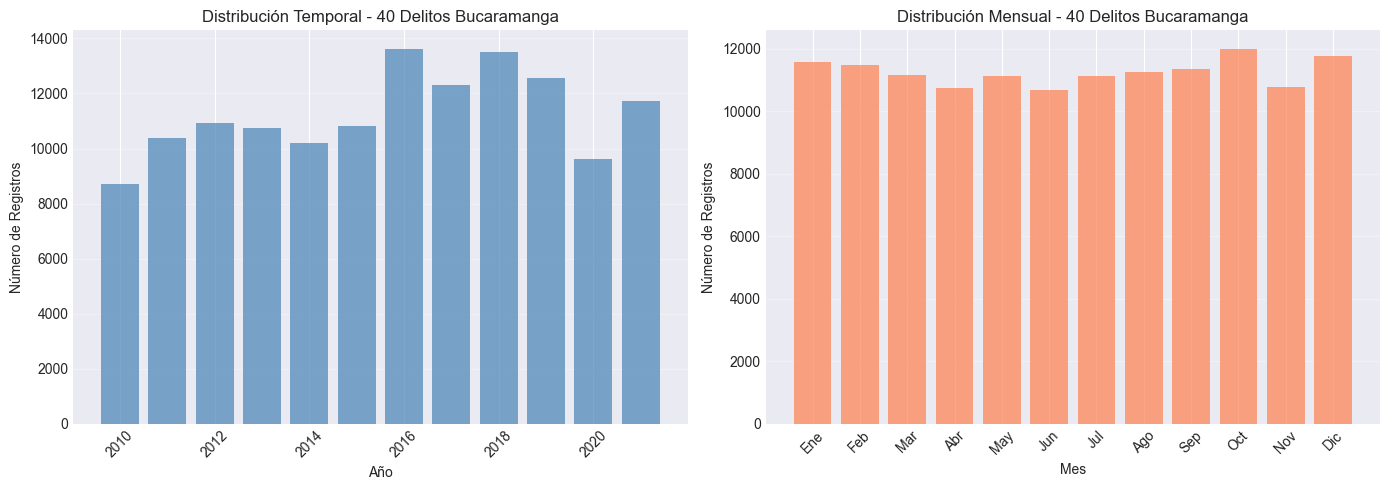


✅ Cobertura temporal completa (sin gaps)

ANÁLISIS TEMPORAL: 150 Información Delictiva Bucaramanga

✅ Fechas parseadas desde columna: fecha_hecho

📅 RANGO TEMPORAL:
  Año más antiguo: 2016
  Año más reciente: 2025
  Años de cobertura: 10

📊 DISTRIBUCIÓN POR AÑO:


,Año,Registros,Porcentaje
0,2016,10770,8.91
1,2017,11004,9.10
2,2018,12479,10.32
3,2019,12892,10.66
4,2020,10363,8.57
5,2021,15369,12.71
6,2022,15750,13.02
7,2023,15295,12.65
8,2024,12921,10.68
9,2025,4097,3.39


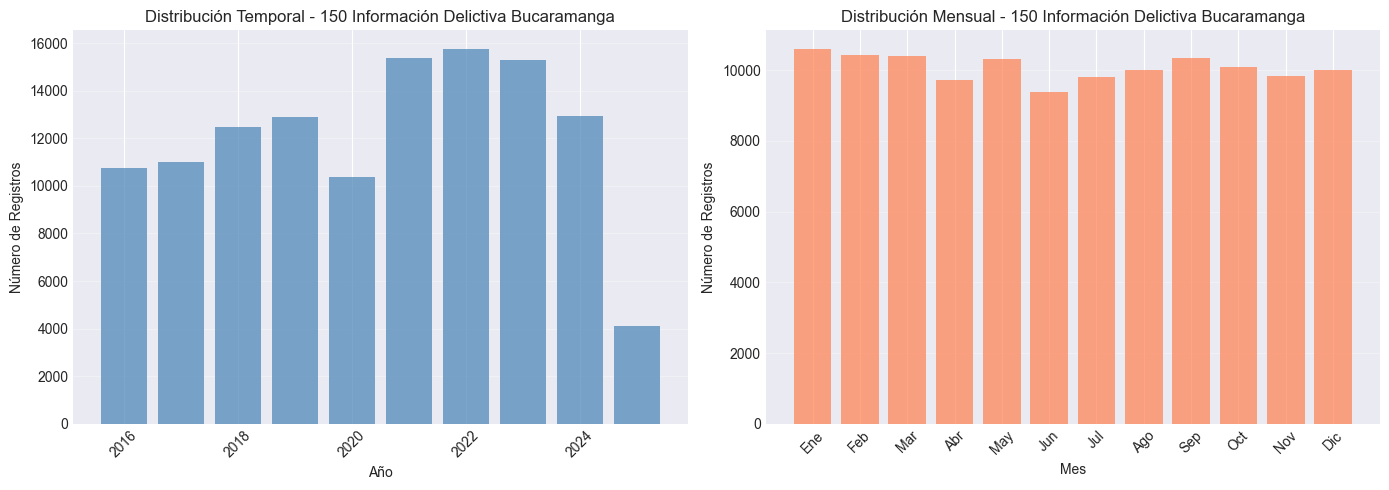


✅ Cobertura temporal completa (sin gaps)

ANÁLISIS TEMPORAL: Delitos Sexuales Nacional

✅ Fechas parseadas desde columna: fecha_hecho

📅 RANGO TEMPORAL:
  Año más antiguo: 2010
  Año más reciente: 2025
  Años de cobertura: 16

📊 DISTRIBUCIÓN POR AÑO:


,Año,Registros,Porcentaje
0,2010,438,2.00
1,2011,487,2.23
2,2012,573,2.62
3,2013,531,2.43
4,2014,491,2.25
5,2015,614,2.81
6,2016,625,2.86
7,2017,767,3.51
8,2018,819,3.75
9,2019,830,3.80


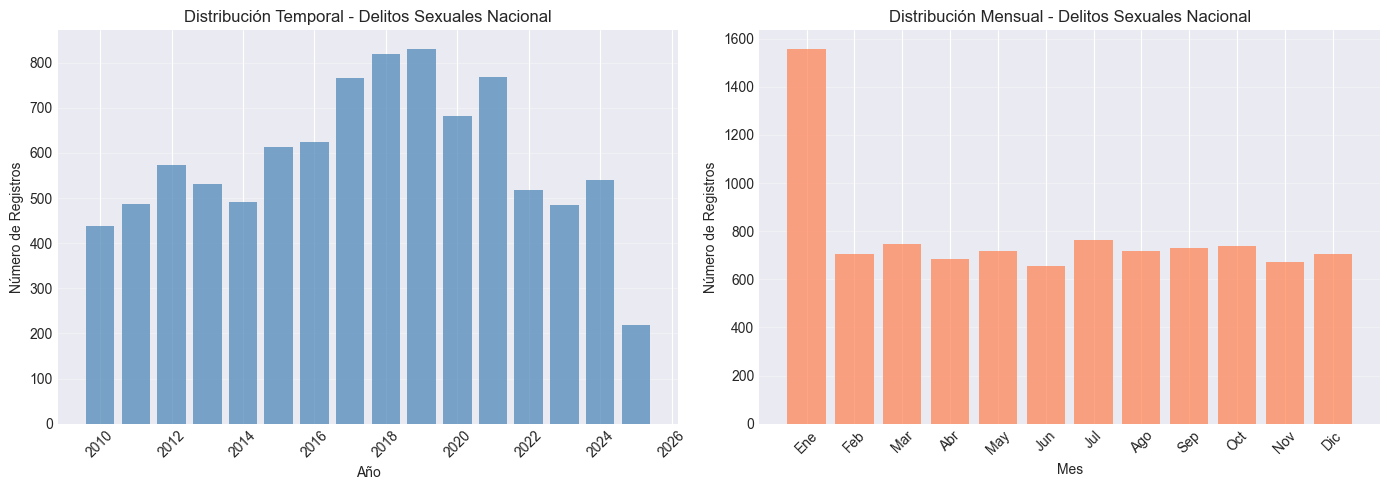


✅ Cobertura temporal completa (sin gaps)

ANÁLISIS TEMPORAL: Violencia Intrafamiliar Nacional

✅ Fechas parseadas desde columna: fecha_hecho

📅 RANGO TEMPORAL:
  Año más antiguo: 2010
  Año más reciente: 2025
  Años de cobertura: 16

📊 DISTRIBUCIÓN POR AÑO:


,Año,Registros,Porcentaje
0,2010,781,1.54
1,2011,914,1.80
2,2012,978,1.92
3,2013,1004,1.97
4,2014,1283,2.52
5,2015,1565,3.08
6,2016,1656,3.26
7,2017,1486,2.92
8,2018,1396,2.74
9,2019,1419,2.79


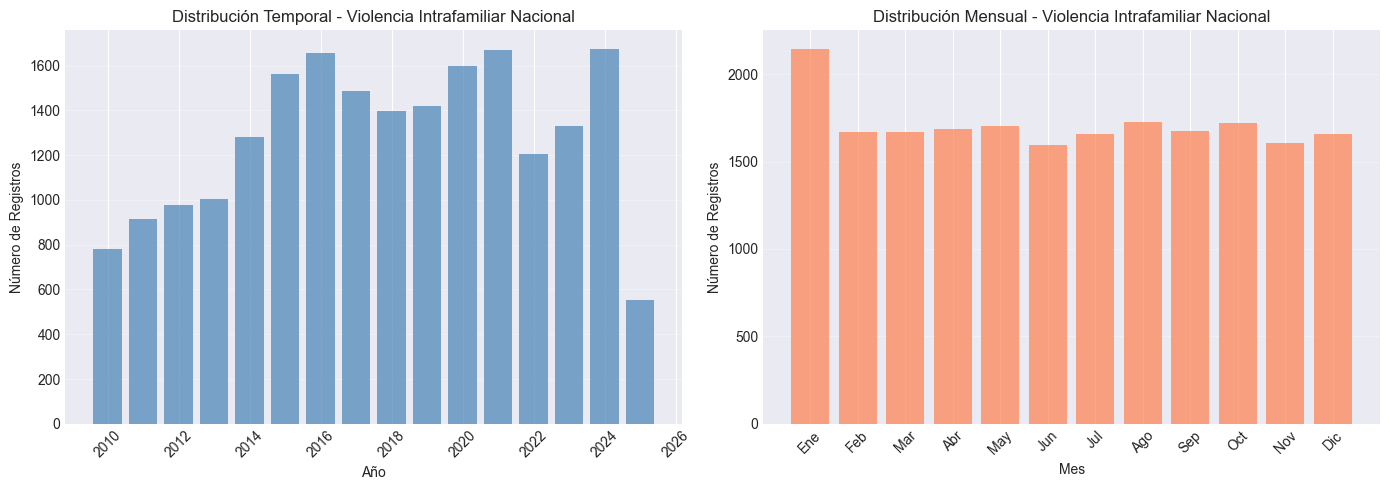


✅ Cobertura temporal completa (sin gaps)

ANÁLISIS TEMPORAL: Hurto por Modalidades Nacional

✅ Fechas parseadas desde columna: fecha_hecho

📅 RANGO TEMPORAL:
  Año más antiguo: 2010
  Año más reciente: 2025
  Años de cobertura: 16

📊 DISTRIBUCIÓN POR AÑO:


,Año,Registros,Porcentaje
0,2010,72,4.98
1,2011,57,3.94
2,2012,55,3.81
3,2013,56,3.88
4,2014,56,3.88
5,2015,63,4.36
6,2016,81,5.61
7,2017,230,15.92
8,2018,155,10.73
9,2019,147,10.17


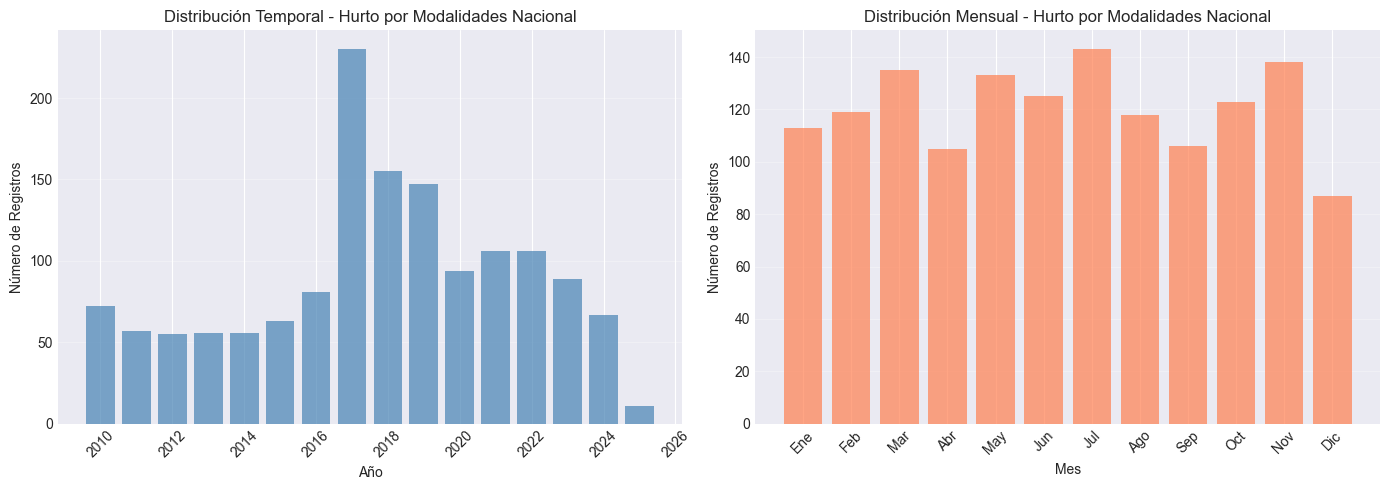


✅ Cobertura temporal completa (sin gaps)


In [18]:
def analyze_temporal_data(df, dataset_name, date_col=None, year_col=None, month_col=None):
    """
    Analiza patrones temporales en los datos.
    """
    print(f"\n{'='*80}")
    print(f"ANÁLISIS TEMPORAL: {dataset_name}")
    print(f"{'='*80}\n")
    
    # Crear columna de fecha si es necesario
    df_temp = df.copy()
    
    if date_col and date_col in df_temp.columns:
        # Dataset con columna de fecha combinada
        try:
            df_temp['fecha_parsed'] = pd.to_datetime(df_temp[date_col], errors='coerce')
            df_temp['año'] = df_temp['fecha_parsed'].dt.year
            df_temp['mes'] = df_temp['fecha_parsed'].dt.month
            print(f"✅ Fechas parseadas desde columna: {date_col}")
        except:
            print(f"⚠️ Error al parsear fechas de columna: {date_col}")
            return
    elif year_col and year_col in df_temp.columns:
        # Dataset con columnas separadas de año/mes
        df_temp['año'] = pd.to_numeric(df_temp[year_col], errors='coerce')
        if month_col and month_col in df_temp.columns:
            # Extraer número del mes si es texto (ej: "01. ENERO" -> 1)
            if df_temp[month_col].dtype == 'object':
                df_temp['mes'] = df_temp[month_col].str.extract(r'(\d+)')[0].astype(float)
            else:
                df_temp['mes'] = pd.to_numeric(df_temp[month_col], errors='coerce')
        print(f"✅ Fechas extraídas desde columnas separadas: {year_col}, {month_col}")
    else:
        print("⚠️ No se encontraron columnas de fecha en el dataset")
        return
    
    # Rango temporal
    if 'año' in df_temp.columns:
        años_validos = df_temp['año'].dropna()
        if len(años_validos) > 0:
            print(f"\n📅 RANGO TEMPORAL:")
            print(f"  Año más antiguo: {int(años_validos.min())}")
            print(f"  Año más reciente: {int(años_validos.max())}")
            print(f"  Años de cobertura: {int(años_validos.max() - años_validos.min() + 1)}")
            
            # Distribución por año
            print(f"\n📊 DISTRIBUCIÓN POR AÑO:")
            year_dist = df_temp['año'].value_counts().sort_index()
            year_df = pd.DataFrame({
                'Año': year_dist.index.astype(int),
                'Registros': year_dist.values,
                'Porcentaje': (year_dist.values / len(df_temp) * 100).round(2)
            })
            display(year_df)
            
            # Visualización
            plt.figure(figsize=(14, 5))
            plt.subplot(1, 2, 1)
            plt.bar(year_df['Año'], year_df['Registros'], color='steelblue', alpha=0.7)
            plt.xlabel('Año')
            plt.ylabel('Número de Registros')
            plt.title(f'Distribución Temporal - {dataset_name}')
            plt.xticks(rotation=45)
            plt.grid(axis='y', alpha=0.3)
            
            # Distribución por mes (si existe)
            if 'mes' in df_temp.columns:
                plt.subplot(1, 2, 2)
                month_dist = df_temp['mes'].value_counts().sort_index()
                meses_nombres = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 
                                'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']
                plt.bar(month_dist.index, month_dist.values, color='coral', alpha=0.7)
                plt.xlabel('Mes')
                plt.ylabel('Número de Registros')
                plt.title(f'Distribución Mensual - {dataset_name}')
                plt.xticks(range(1, 13), meses_nombres, rotation=45)
                plt.grid(axis='y', alpha=0.3)
            
            plt.tight_layout()
            plt.show()
            
            # Detectar gaps temporales
            all_years = set(range(int(años_validos.min()), int(años_validos.max()) + 1))
            present_years = set(year_dist.index.astype(int))
            missing_years = all_years - present_years
            
            if missing_years:
                print(f"\n⚠️ AÑOS SIN DATOS: {sorted(missing_years)}")
            else:
                print(f"\n✅ Cobertura temporal completa (sin gaps)")

# Analizar temporalidad de cada dataset
temporal_configs = {
    'delitos_bucaramanga': {'year_col': 'ano', 'month_col': 'mes'},
    'info_delictiva_bucaramanga': {'date_col': 'fecha_hecho'},
    'delitos_sexuales': {'date_col': 'fecha_hecho'},
    'violencia_intrafamiliar': {'date_col': 'fecha_hecho'},
    'hurto_modalidades': {'date_col': 'fecha_hecho'}
}

for key, df in dataframes.items():
    if len(df) > 0:
        config = temporal_configs.get(key, {})
        analyze_temporal_data(df, DATASETS[key]['name'], **config)

## 8. Análisis Geográfico

Exploramos la distribución geográfica de los datos (departamento, municipio).


ANÁLISIS GEOGRÁFICO: 40 Delitos Bucaramanga


🏙️ DISTRIBUCIÓN POR MUNICIPIO:
Total de municipios únicos: 484

Top 15 municipios con más registros:


,Municipio,Registros,Porcentaje
0,CENTRO,11199,8.29
1,SAN FRANCISCO,5944,4.40
2,CABECERA DEL LLANO,5794,4.29
3,LA CONCORDIA,5078,3.76
4,PROVENZA,3447,2.55
5,SAN ALONSO,3441,2.55
6,CAMPO HERMOSO,2784,2.06
7,GARCIA ROVIRA,2676,1.98
8,SOTOMAYOR,2668,1.98
9,GIRARDOT,2608,1.93


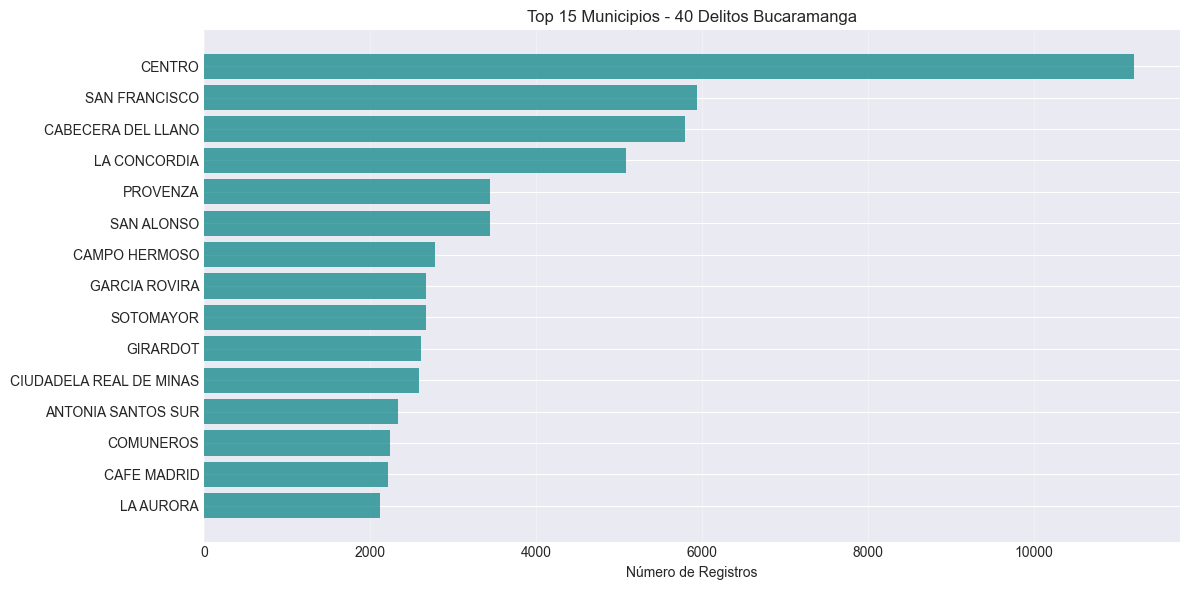


📊 Concentración geográfica:
  - Top 5 municipios: 23.29% de los datos
  - Top 10 municipios: 33.79% de los datos

ANÁLISIS GEOGRÁFICO: 150 Información Delictiva Bucaramanga


🏙️ DISTRIBUCIÓN POR MUNICIPIO:
Total de municipios únicos: 263

Top 15 municipios con más registros:


,Municipio,Registros,Porcentaje
0,CENTRO,10154,8.40
1,CABECERA DEL LLANO,6274,5.19
2,SAN FRANCISCO,5582,4.62
3,LA CONCORDIA,4261,3.52
4,SAN ALONSO,3325,2.75
5,PROVENZA,2939,2.43
6,CIUDADELA REAL DE MINAS,2908,2.40
7,GARCIA ROVIRA,2504,2.07
8,ANTONIA SANTOS CENTRO,2504,2.07
9,CAFE MADRID,2427,2.01


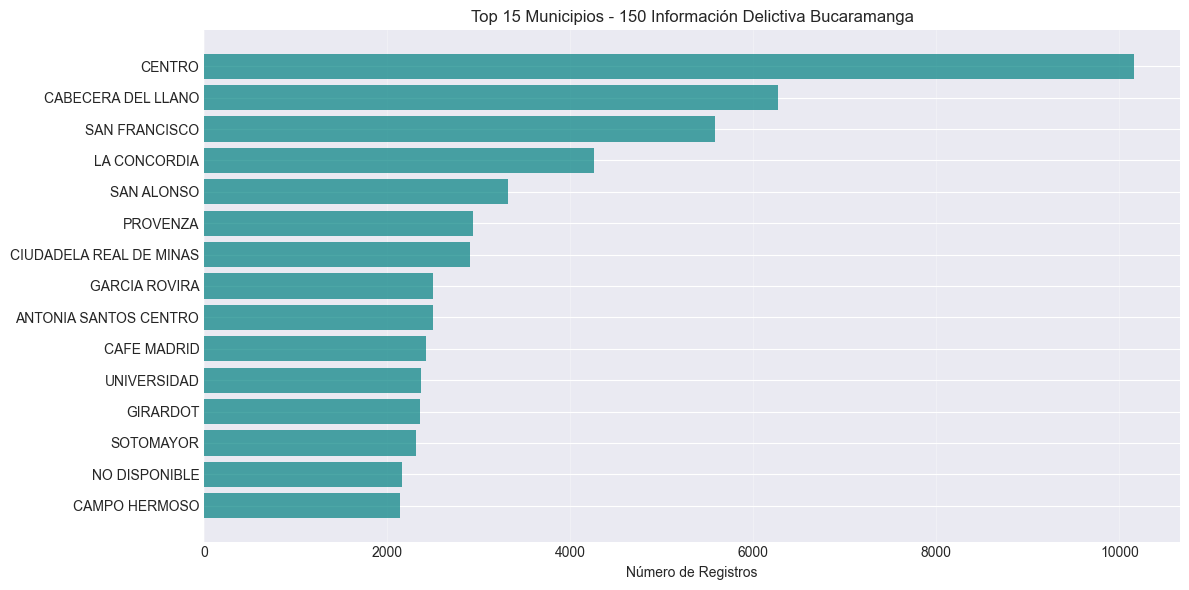


📊 Concentración geográfica:
  - Top 5 municipios: 24.47% de los datos
  - Top 10 municipios: 35.45% de los datos

ANÁLISIS GEOGRÁFICO: Delitos Sexuales Nacional

📍 DISTRIBUCIÓN POR DEPARTAMENTO:


,Departamento,Registros,Porcentaje
0,SANTANDER,21859,100.0



✅ Santander representa el 100.00% de los datos

🏙️ DISTRIBUCIÓN POR MUNICIPIO:
Total de municipios únicos: 87

Top 15 municipios con más registros:


,Municipio,Registros,Porcentaje
0,Bucaramanga (CT),6256,28.62
1,Barrancabermeja,2565,11.73
2,Floridablanca,2370,10.84
3,Girón,1616,7.39
4,Piedecuesta,1486,6.80
5,San Gil,646,2.96
6,Sabana de Torres,485,2.22
7,Cimitarra,479,2.19
8,Lebrija,399,1.83
9,San Vicente de Chucurí,370,1.69


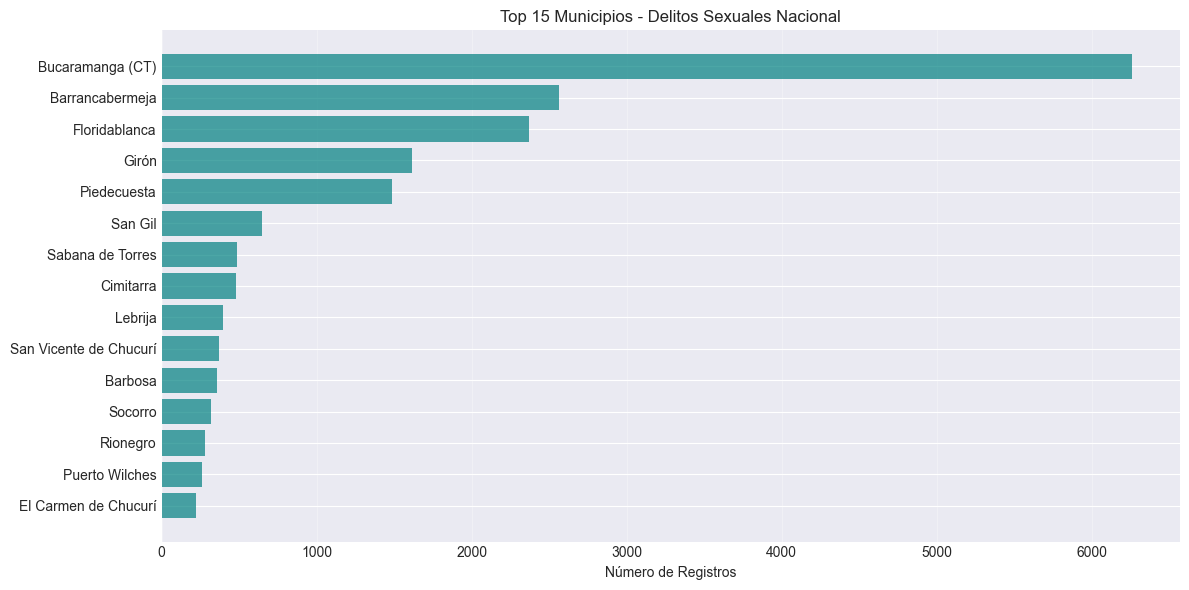


📊 Concentración geográfica:
  - Top 5 municipios: 65.39% de los datos
  - Top 10 municipios: 76.27% de los datos

ANÁLISIS GEOGRÁFICO: Violencia Intrafamiliar Nacional

📍 DISTRIBUCIÓN POR DEPARTAMENTO:


,Departamento,Registros,Porcentaje
0,SANTANDER,50864,100.0



✅ Santander representa el 100.00% de los datos

🏙️ DISTRIBUCIÓN POR MUNICIPIO:
Total de municipios únicos: 87

Top 15 municipios con más registros:


,Municipio,Registros,Porcentaje
0,Bucaramanga (CT),12766,25.10
1,Barrancabermeja,7373,14.50
2,Floridablanca,6516,12.81
3,Girón,6029,11.85
4,Piedecuesta,3995,7.85
5,San Gil,1474,2.90
6,Barbosa,1093,2.15
7,Socorro,805,1.58
8,Sabana de Torres,797,1.57
9,Cimitarra,773,1.52


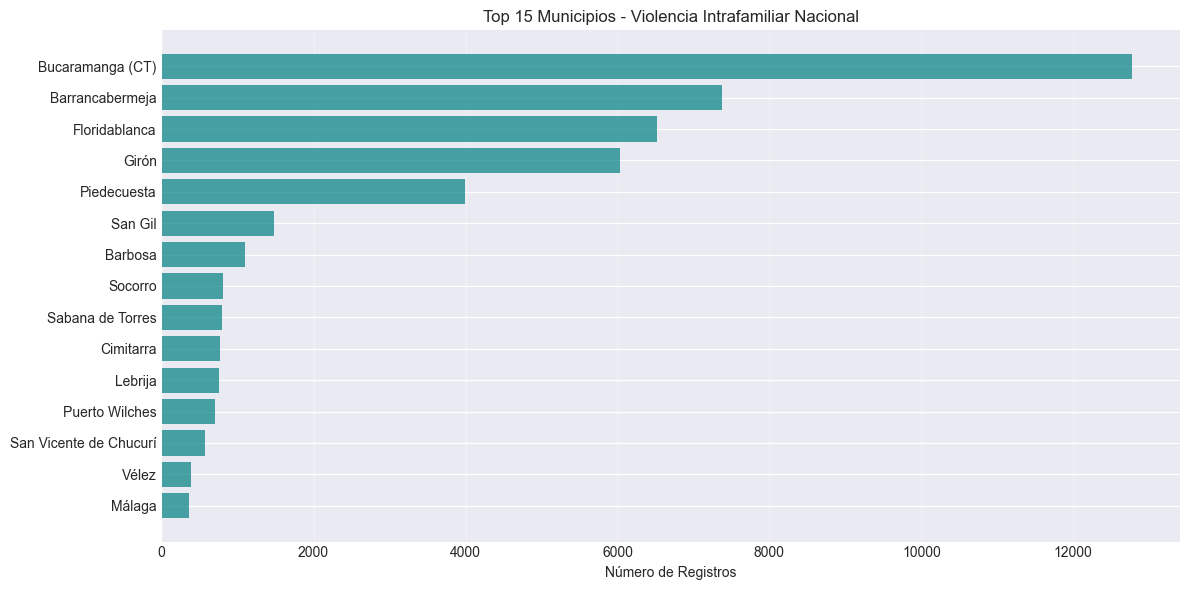


📊 Concentración geográfica:
  - Top 5 municipios: 72.11% de los datos
  - Top 10 municipios: 81.83% de los datos

ANÁLISIS GEOGRÁFICO: Hurto por Modalidades Nacional

📍 DISTRIBUCIÓN POR DEPARTAMENTO:


,Departamento,Registros,Porcentaje
0,SANTANDER,1445,100.0



✅ Santander representa el 100.00% de los datos

🏙️ DISTRIBUCIÓN POR MUNICIPIO:
Total de municipios únicos: 81

Top 15 municipios con más registros:


,Municipio,Registros,Porcentaje
0,Barrancabermeja,322,22.28
1,Cimitarra,109,7.54
2,Sabana de Torres,100,6.92
3,Puerto Wilches,76,5.26
4,Puente Nacional,48,3.32
5,Vélez,48,3.32
6,Rionegro,47,3.25
7,Puerto Parra,42,2.91
8,Bucaramanga (CT),40,2.77
9,San Vicente de Chucurí,34,2.35


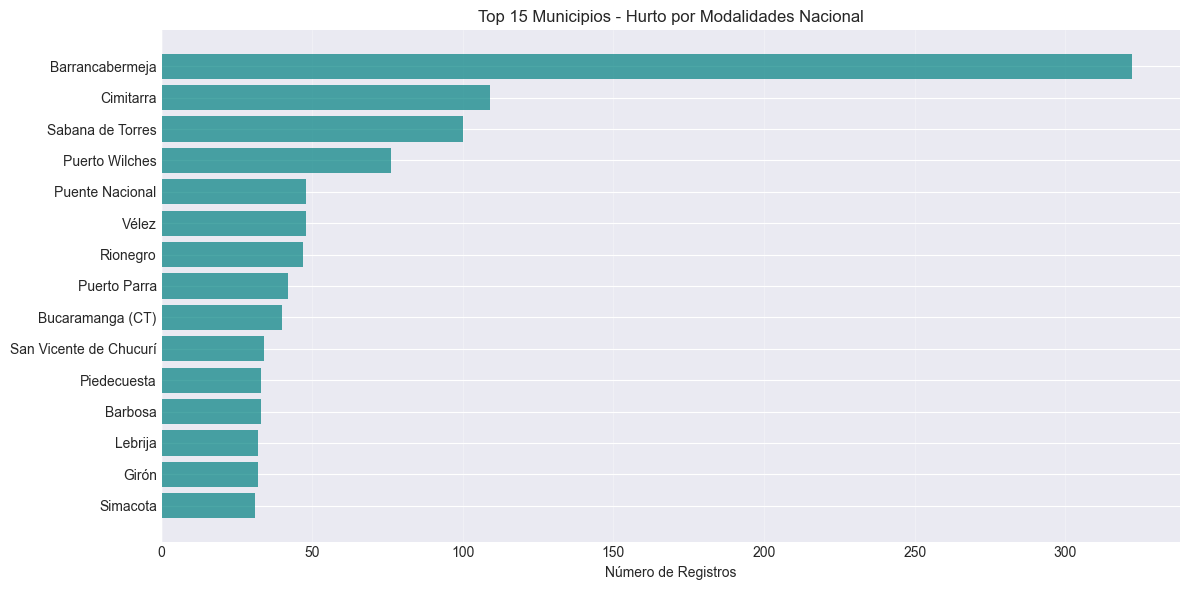


📊 Concentración geográfica:
  - Top 5 municipios: 45.33% de los datos
  - Top 10 municipios: 59.93% de los datos


In [19]:
def analyze_geographic_data(df, dataset_name, dept_col=None, muni_col=None):
    """
    Analiza la distribución geográfica de los datos.
    """
    print(f"\n{'='*80}")
    print(f"ANÁLISIS GEOGRÁFICO: {dataset_name}")
    print(f"{'='*80}\n")
    
    # Análisis de departamento
    if dept_col and dept_col in df.columns:
        print(f"📍 DISTRIBUCIÓN POR DEPARTAMENTO:")
        dept_dist = df[dept_col].value_counts()
        dept_df = pd.DataFrame({
            'Departamento': dept_dist.index,
            'Registros': dept_dist.values,
            'Porcentaje': (dept_dist.values / len(df) * 100).round(2)
        })
        display(dept_df.head(10))
        
        # Verificar filtro de Santander
        if 'SANTANDER' in dept_dist.index:
            santander_pct = dept_dist['SANTANDER'] / len(df) * 100
            print(f"\n✅ Santander representa el {santander_pct:.2f}% de los datos")
        else:
            print(f"\n⚠️ No se encontraron registros de Santander")
    
    # Análisis de municipio
    if muni_col and muni_col in df.columns:
        print(f"\n🏙️ DISTRIBUCIÓN POR MUNICIPIO:")
        muni_dist = df[muni_col].value_counts()
        
        print(f"Total de municipios únicos: {len(muni_dist)}")
        print(f"\nTop 15 municipios con más registros:")
        
        muni_df = pd.DataFrame({
            'Municipio': muni_dist.head(15).index,
            'Registros': muni_dist.head(15).values,
            'Porcentaje': (muni_dist.head(15).values / len(df) * 100).round(2)
        })
        display(muni_df.reset_index(drop=True))
        
        # Visualización
        plt.figure(figsize=(12, 6))
        top_15 = muni_dist.head(15)
        plt.barh(range(len(top_15)), top_15.values, color='teal', alpha=0.7)
        plt.yticks(range(len(top_15)), top_15.index)
        plt.xlabel('Número de Registros')
        plt.title(f'Top 15 Municipios - {dataset_name}')
        plt.gca().invert_yaxis()
        plt.grid(axis='x', alpha=0.3)
        plt.tight_layout()
        plt.show()
        
        # Estadísticas de concentración
        top_5_pct = (muni_dist.head(5).sum() / len(df) * 100)
        top_10_pct = (muni_dist.head(10).sum() / len(df) * 100)
        print(f"\n📊 Concentración geográfica:")
        print(f"  - Top 5 municipios: {top_5_pct:.2f}% de los datos")
        print(f"  - Top 10 municipios: {top_10_pct:.2f}% de los datos")

# Configuración geográfica por dataset
geo_configs = {
    'delitos_bucaramanga': {'muni_col': 'barrios_hecho'},  # Solo Bucaramanga (barrios)
    'info_delictiva_bucaramanga': {'muni_col': 'barrios_hecho'},  # Solo Bucaramanga (barrios)
    'delitos_sexuales': {'dept_col': 'departamento', 'muni_col': 'municipio'},
    'violencia_intrafamiliar': {'dept_col': 'departamento', 'muni_col': 'municipio'},
    'hurto_modalidades': {'dept_col': 'departamento', 'muni_col': 'municipio'}
}

for key, df in dataframes.items():
    if len(df) > 0:
        config = geo_configs.get(key, {})
        analyze_geographic_data(df, DATASETS[key]['name'], **config)

## 9. Análisis de Tipos de Delitos

Exploramos las categorías y tipos de delitos en cada dataset.


ANÁLISIS DE TIPOS DE DELITOS: 40 Delitos Bucaramanga

📊 Total de tipos de delitos únicos: 41

Top 20 delitos más frecuentes:


,Delito,Frecuencia,Porcentaje
0,HURTO A PERSONAS,48452,35.87
1,LESIONES PERSONALES,24450,18.10
2,LESIONES CULPOSAS ( EN ACCIDENTE DE TRANSITO ),21130,15.64
3,VIOLENCIA INTRAFAMILIAR,16519,12.23
4,HURTO A ENTIDADES COMERCIALES,8937,6.62
5,HURTO A RESIDENCIAS,4752,3.52
6,HURTO A MOTOCICLETAS,3708,2.75
7,ACTOS SEXUALES CON MENOR DE 14 AÑOS,1529,1.13
8,HOMICIDIO,1365,1.01
9,ACCESO CARNAL ABUSIVO CON MENOR DE 14 AÑOS,805,0.60


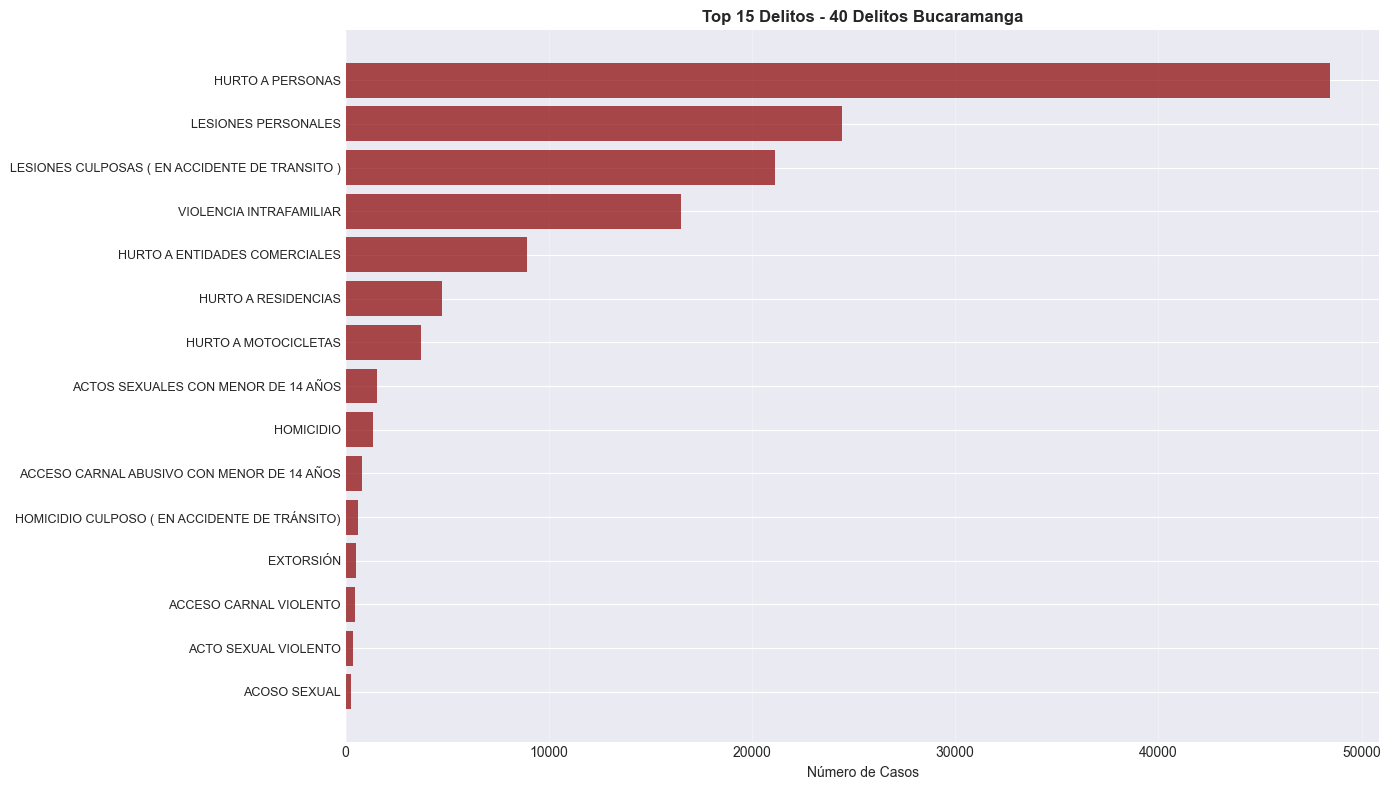


📈 Concentración de delitos:
  - Top 5 delitos: 88.46% de los casos
  - Top 10 delitos: 97.46% de los casos

ANÁLISIS DE TIPOS DE DELITOS: 150 Información Delictiva Bucaramanga

📊 Total de tipos de delitos únicos: 44

Top 20 delitos más frecuentes:


,Delito,Frecuencia,Porcentaje
0,HURTO PERSONAS,56518,46.73
1,LESIONES PERSONALES,16693,13.80
2,VIOLENCIA INTRAFAMILIAR,16601,13.73
3,HURTO ENTIDADES COMERCIALES,8764,7.25
4,HURTO MOTOCICLETAS,4769,3.94
5,HURTO RESIDENCIAS,4224,3.49
6,LESIONES CULPOSAS ( EN ACCIDENTE DE TRANSITO ),3432,2.84
7,AMENAZAS,3365,2.78
8,ACTOS SEXUALES CON MENOR DE 14 AÑOS,1605,1.33
9,HOMICIDIO,1030,0.85


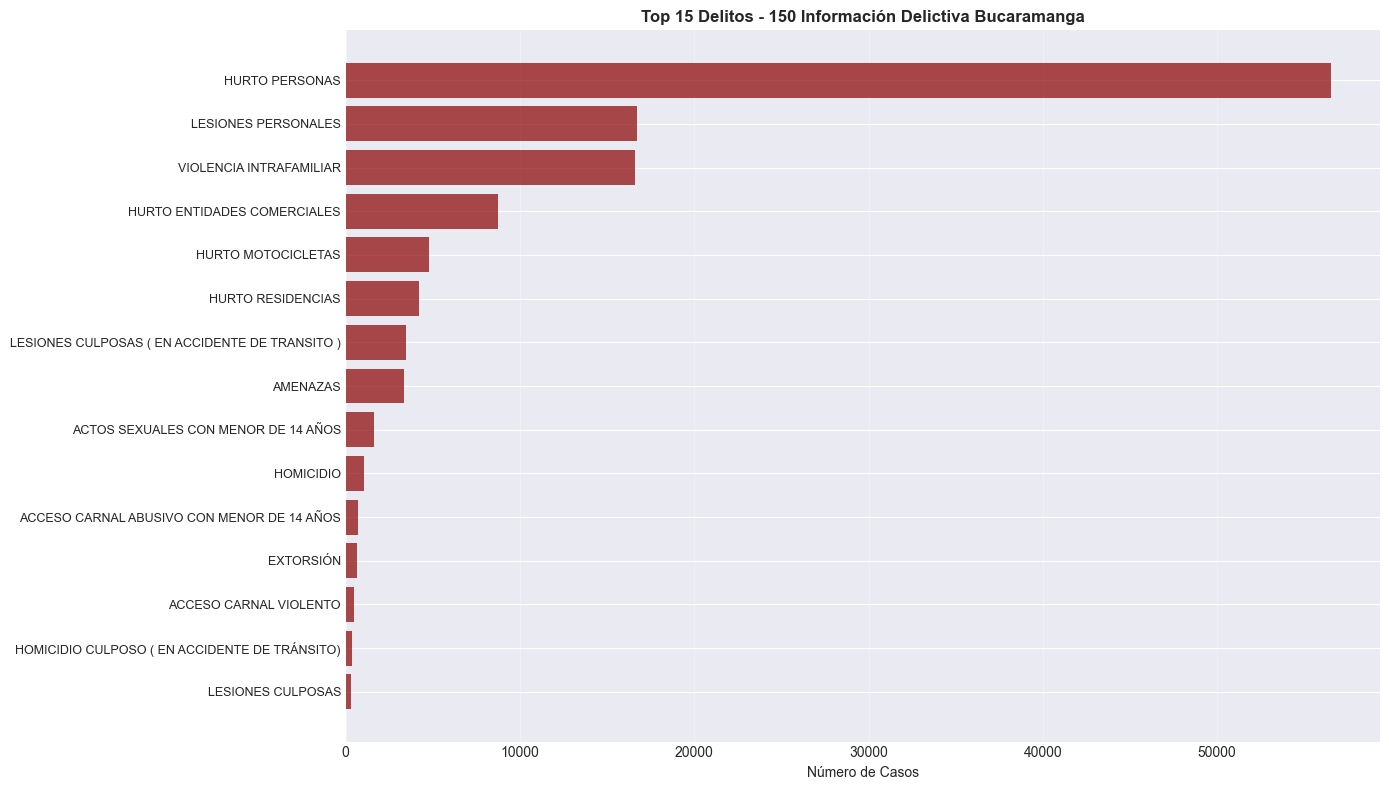


📈 Concentración de delitos:
  - Top 5 delitos: 85.45% de los casos
  - Top 10 delitos: 96.74% de los casos

ANÁLISIS DE TIPOS DE DELITOS: Delitos Sexuales Nacional

📊 Total de tipos de delitos únicos: 22

Top 20 delitos más frecuentes:


,Delito,Frecuencia,Porcentaje
0,ARTÍCULO 209. ACTOS SEXUALES CON MENOR DE 14 AÑOS,8840,40.44
1,ARTÍCULO 208. ACCESO CARNAL ABUSIVO CON MENOR ...,4641,21.23
2,ARTÍCULO 205. ACCESO CARNAL VIOLENTO,2665,12.19
3,ARTÍCULO 206. ACTO SEXUAL VIOLENTO,1888,8.64
4,ARTÍCULO 210 A. ACOSO SEXUAL,1142,5.22
5,ARTÍCULO 210. ACCESO CARNAL O ACTO SEXUAL ABUS...,1031,4.72
6,ARTÍCULO 218. PORNOGRAFÍA CON MENORES,447,2.04
7,ARTÍCULO 207. ACCESO CARNAL O ACTO SEXUAL EN P...,402,1.84
8,ARTÍCULO 219 A. UTILIZACIÓN O FACILITACIÓN DE ...,256,1.17
9,ARTÍCULO 213. INDUCCIÓN A LA PROSTITUCIÓN,187,0.86


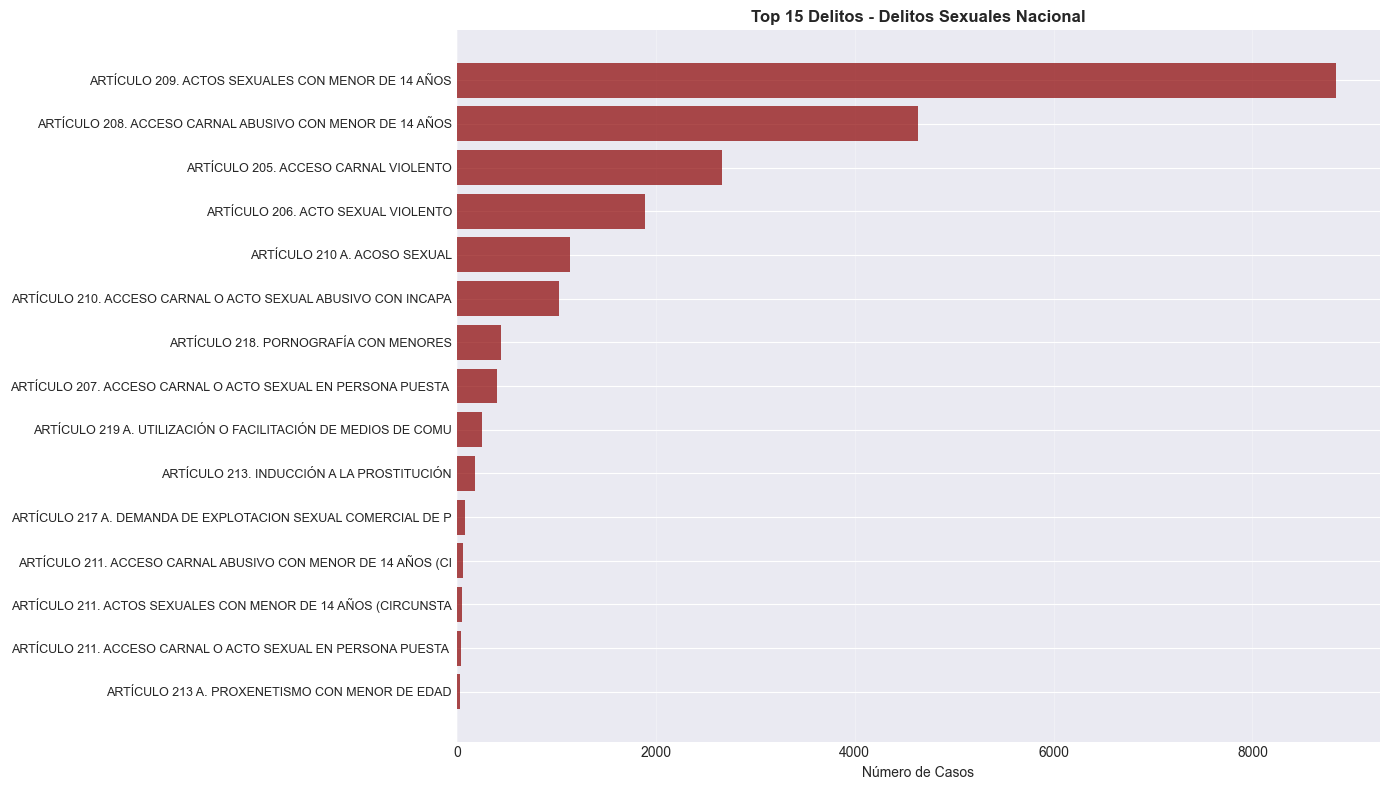


📈 Concentración de delitos:
  - Top 5 delitos: 87.73% de los casos
  - Top 10 delitos: 98.35% de los casos

ANÁLISIS DE TIPOS DE DELITOS: Violencia Intrafamiliar Nacional

⚠️ No se encontró columna de tipo de delito

ANÁLISIS DE TIPOS DE DELITOS: Hurto por Modalidades Nacional

📊 Total de tipos de delitos únicos: 3

Top 20 delitos más frecuentes:


,Delito,Frecuencia,Porcentaje
0,HURTO ABIGEATO,1293,89.48
1,HURTO PIRATERÍA TERRESTRE,104,7.20
2,HURTO ENTIDADES FINANCIERAS,48,3.32


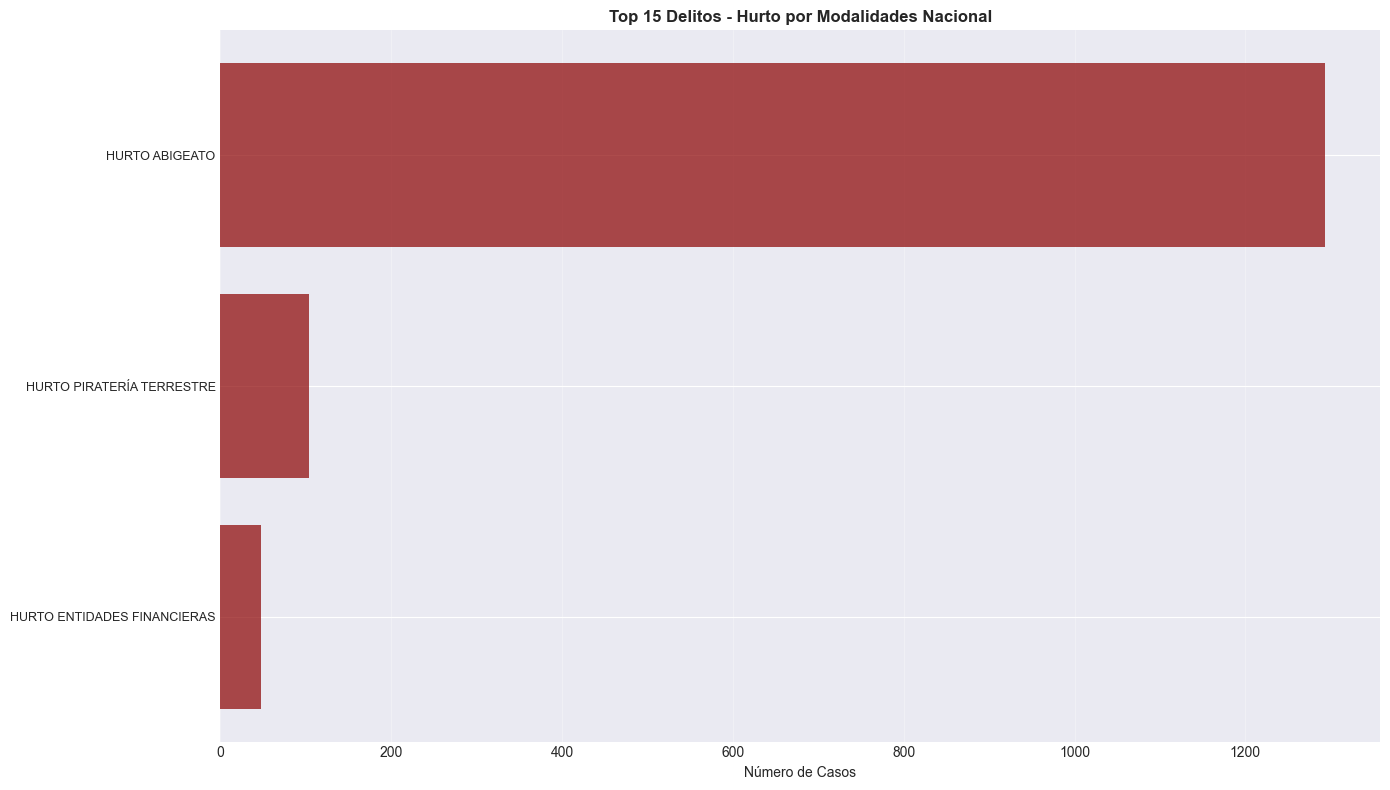


📈 Concentración de delitos:
  - Top 5 delitos: 100.00% de los casos
  - Top 10 delitos: 100.00% de los casos


In [20]:
def analyze_crime_types(df, dataset_name, crime_col=None):
    """
    Analiza los tipos de delitos en el dataset.
    """
    print(f"\n{'='*80}")
    print(f"ANÁLISIS DE TIPOS DE DELITOS: {dataset_name}")
    print(f"{'='*80}\n")
    
    if not crime_col or crime_col not in df.columns:
        print("⚠️ No se encontró columna de tipo de delito")
        return
    
    crime_dist = df[crime_col].value_counts()
    
    print(f"📊 Total de tipos de delitos únicos: {len(crime_dist)}")
    print(f"\nTop 20 delitos más frecuentes:")
    
    crime_df = pd.DataFrame({
        'Delito': crime_dist.head(20).index,
        'Frecuencia': crime_dist.head(20).values,
        'Porcentaje': (crime_dist.head(20).values / len(df) * 100).round(2)
    })
    display(crime_df.reset_index(drop=True))
    
    # Visualización
    plt.figure(figsize=(14, 8))
    top_15 = crime_dist.head(15)
    plt.barh(range(len(top_15)), top_15.values, color='darkred', alpha=0.7)
    plt.yticks(range(len(top_15)), [str(x)[:60] for x in top_15.index], fontsize=9)
    plt.xlabel('Número de Casos')
    plt.title(f'Top 15 Delitos - {dataset_name}', fontsize=12, fontweight='bold')
    plt.gca().invert_yaxis()
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # Concentración
    top_5_pct = (crime_dist.head(5).sum() / len(df) * 100)
    top_10_pct = (crime_dist.head(10).sum() / len(df) * 100)
    print(f"\n📈 Concentración de delitos:")
    print(f"  - Top 5 delitos: {top_5_pct:.2f}% de los casos")
    print(f"  - Top 10 delitos: {top_10_pct:.2f}% de los casos")

# Configuración de columnas de delitos por dataset
crime_configs = {
    'delitos_bucaramanga': 'conducta',
    'info_delictiva_bucaramanga': 'delito_solo',
    'delitos_sexuales': 'delito',
    'violencia_intrafamiliar': None,  # No tiene columna específica de tipo
    'hurto_modalidades': 'tipo_de_hurto'
}

for key, df in dataframes.items():
    if len(df) > 0:
        crime_col = crime_configs.get(key)
        analyze_crime_types(df, DATASETS[key]['name'], crime_col)

## 10. Análisis Demográfico

Analizamos variables demográficas (género, edad) de víctimas.


ANÁLISIS DEMOGRÁFICO: 40 Delitos Bucaramanga


🎂 DISTRIBUCIÓN POR GRUPO ETARIO:


,Grupo Etario,Casos,Porcentaje
0,05. ADULTEZ,62516,46.28
1,04. JOVENES,43462,32.18
2,NO REPORTA,10001,7.40
3,03. ADOLESCENCIA,7511,5.56
4,06. PERSONA MAYOR,7487,5.54
5,02. INFANCIA,1781,1.32
6,01. PRIMERA INFANCIA,1378,1.02
7,ERROR: #N/A,940,0.70


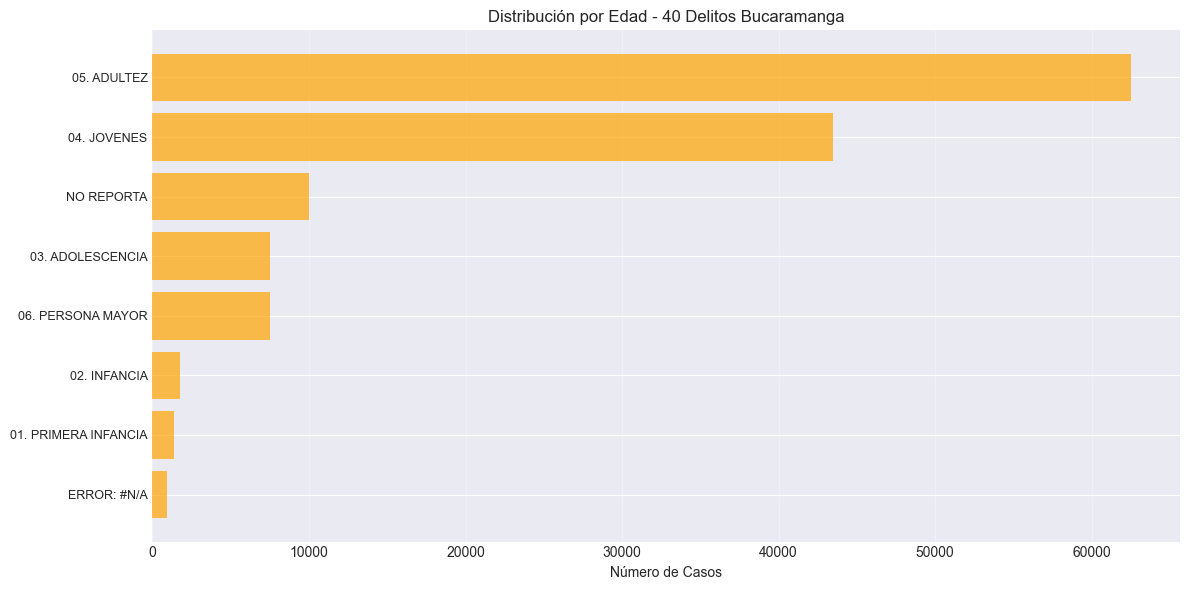


ANÁLISIS DEMOGRÁFICO: 150 Información Delictiva Bucaramanga

👥 DISTRIBUCIÓN POR GÉNERO:


,Género,Casos,Porcentaje
0,FEMENINO,56742,46.92
1,MASCULINO,53872,44.54
2,NO DISPONIBLE,10326,8.54



🎂 DISTRIBUCIÓN POR GRUPO ETARIO:


,Grupo Etario,Casos,Porcentaje
0,NO DISPONIBLE,31859,26.34
1,25-29,13952,11.54
2,20-24,13159,10.88
3,30-34,12285,10.16
4,35-39,10032,8.30
5,40-44,8104,6.70
6,15-19,6453,5.34
7,45-49,6219,5.14
8,50-54,4905,4.06
9,55-59,3644,3.01


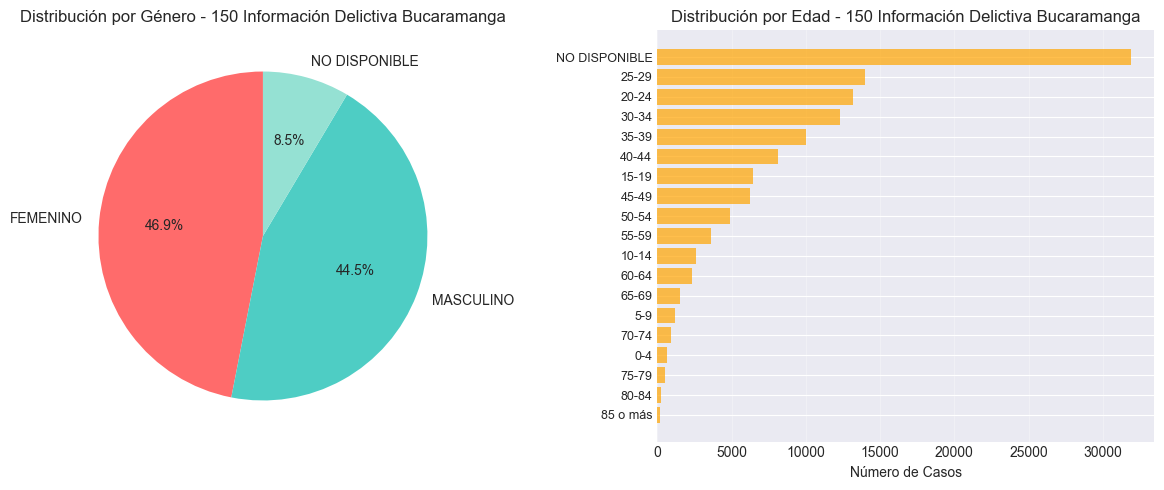


ANÁLISIS DEMOGRÁFICO: Delitos Sexuales Nacional

👥 DISTRIBUCIÓN POR GÉNERO:


,Género,Casos,Porcentaje
0,FEMENINO,18592,85.05
1,MASCULINO,3200,14.64
2,NO REPORTA,44,0.20
3,NO REPORTADO,23,0.11



🎂 DISTRIBUCIÓN POR GRUPO ETARIO:


,Grupo Etario,Casos,Porcentaje
0,NO REPORTADO,18959,86.73
1,ADULTOS,1732,7.92
2,ADOLESCENTES,598,2.74
3,MENORES,570,2.61


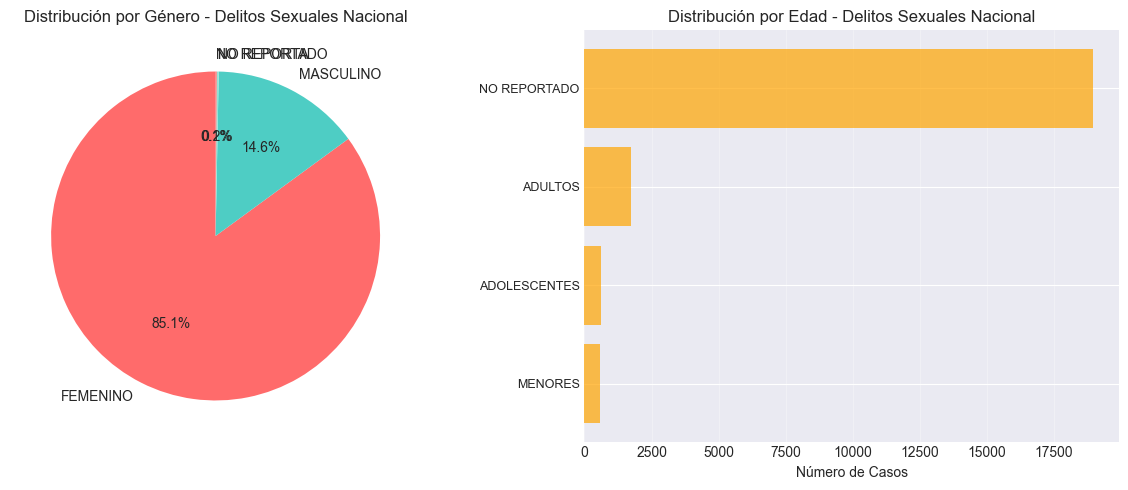


ANÁLISIS DEMOGRÁFICO: Violencia Intrafamiliar Nacional

👥 DISTRIBUCIÓN POR GÉNERO:


,Género,Casos,Porcentaje
0,FEMENINO,38633,75.95
1,MASCULINO,12200,23.99
2,NO REPORTA,6,0.01



🎂 DISTRIBUCIÓN POR GRUPO ETARIO:


,Grupo Etario,Casos,Porcentaje
0,ADULTOS,47519,93.42
1,ADOLESCENTES,2088,4.11
2,MENORES,1251,2.46


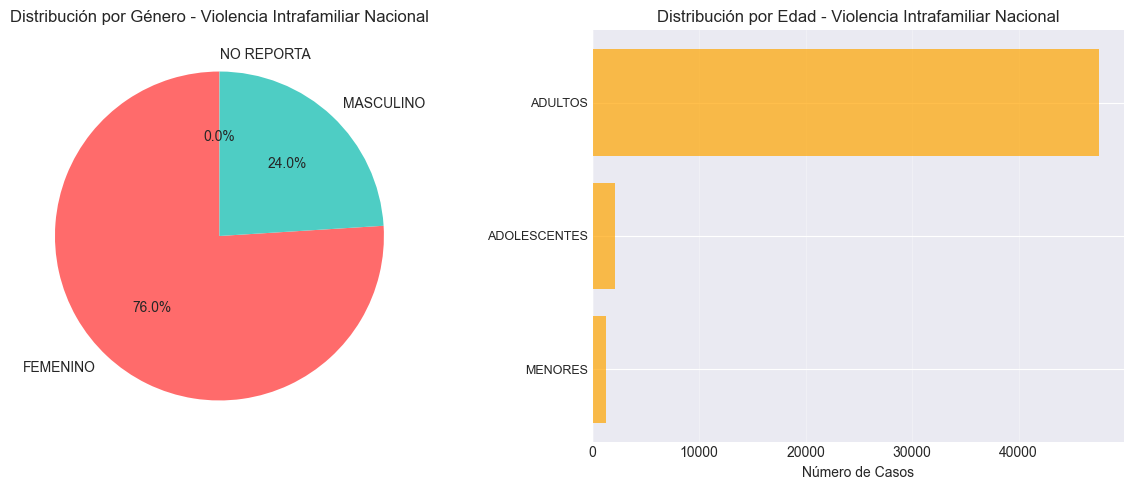


ANÁLISIS DEMOGRÁFICO: Hurto por Modalidades Nacional

👥 DISTRIBUCIÓN POR GÉNERO:


,Género,Casos,Porcentaje
0,MASCULINO,1092,75.57
1,FEMENINO,267,18.48
2,NO REPORTADO,85,5.88
3,NO REPORTA,1,0.07



🎂 DISTRIBUCIÓN POR GRUPO ETARIO:


,Grupo Etario,Casos,Porcentaje
0,NO REPORTADO,1278,88.44
1,ADULTOS,167,11.56


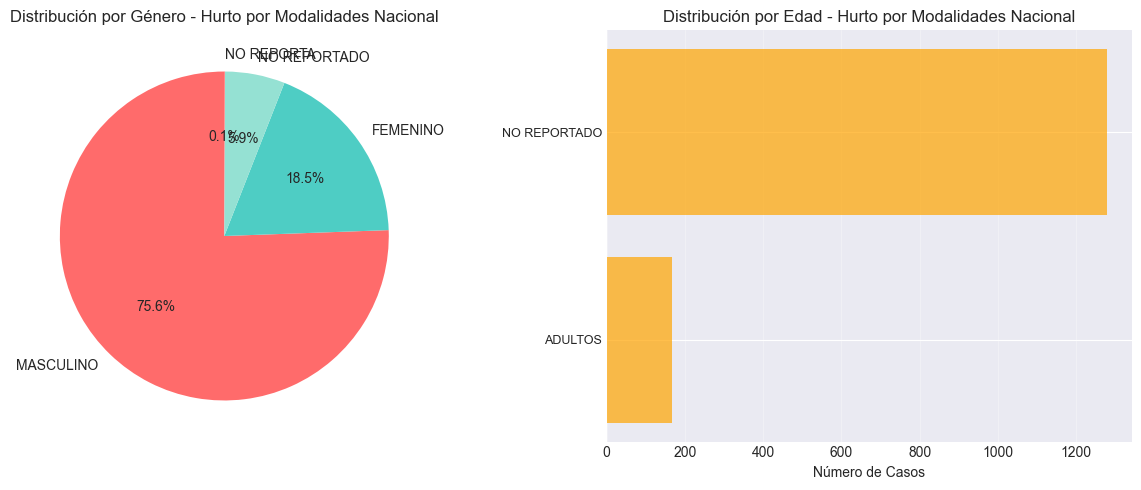

In [21]:
def analyze_demographics(df, dataset_name, gender_col=None, age_col=None):
    """
    Analiza variables demográficas de las víctimas.
    """
    print(f"\n{'='*80}")
    print(f"ANÁLISIS DEMOGRÁFICO: {dataset_name}")
    print(f"{'='*80}\n")
    
    # Análisis de género
    if gender_col and gender_col in df.columns:
        print(f"👥 DISTRIBUCIÓN POR GÉNERO:")
        gender_dist = df[gender_col].value_counts()
        gender_df = pd.DataFrame({
            'Género': gender_dist.index,
            'Casos': gender_dist.values,
            'Porcentaje': (gender_dist.values / len(df) * 100).round(2)
        })
        display(gender_df.reset_index(drop=True))
        
        # Visualización
        plt.figure(figsize=(12, 5))
        
        plt.subplot(1, 2, 1)
        colors = ['#FF6B6B', '#4ECDC4', '#95E1D3']
        plt.pie(gender_dist.values, labels=gender_dist.index, autopct='%1.1f%%', 
                colors=colors[:len(gender_dist)], startangle=90)
        plt.title(f'Distribución por Género - {dataset_name}')
    
    # Análisis de edad/grupo etario
    if age_col and age_col in df.columns:
        if gender_col and gender_col in df.columns:
            plt.subplot(1, 2, 2)
        else:
            plt.figure(figsize=(12, 6))
            
        print(f"\n🎂 DISTRIBUCIÓN POR GRUPO ETARIO:")
        age_dist = df[age_col].value_counts()
        age_df = pd.DataFrame({
            'Grupo Etario': age_dist.index,
            'Casos': age_dist.values,
            'Porcentaje': (age_dist.values / len(df) * 100).round(2)
        })
        display(age_df.reset_index(drop=True))
        
        plt.barh(range(len(age_dist)), age_dist.values, color='orange', alpha=0.7)
        plt.yticks(range(len(age_dist)), age_dist.index, fontsize=9)
        plt.xlabel('Número de Casos')
        plt.title(f'Distribución por Edad - {dataset_name}')
        plt.gca().invert_yaxis()
        plt.grid(axis='x', alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Configuración demográfica por dataset
demo_configs = {
    'delitos_bucaramanga': {'gender_col': None, 'age_col': 'curso_de_vida'},
    'info_delictiva_bucaramanga': {'gender_col': 'sexo', 'age_col': 'curso_vida'},
    'delitos_sexuales': {'gender_col': 'genero', 'age_col': 'grupo_etario'},
    'violencia_intrafamiliar': {'gender_col': 'genero', 'age_col': 'grupo_etario'},
    'hurto_modalidades': {'gender_col': 'genero', 'age_col': 'grupo_etario'}
}

for key, df in dataframes.items():
    if len(df) > 0:
        config = demo_configs.get(key, {})
        analyze_demographics(df, DATASETS[key]['name'], **config)

## 11. Detección de Problemas de Calidad de Datos

Identificamos problemas específicos en cada dataset que requieren atención.

In [22]:
def detect_data_quality_issues(df, dataset_name):
    """
    Detecta problemas de calidad de datos en un DataFrame.
    """
    print(f"\n{'='*80}")
    print(f"PROBLEMAS DE CALIDAD DE DATOS: {dataset_name}")
    print(f"{'='*80}\n")
    
    issues = []
    
    # 1. Duplicados completos
    duplicates = df.duplicated().sum()
    if duplicates > 0:
        issues.append({
            'Tipo': 'Registros duplicados',
            'Cantidad': duplicates,
            'Porcentaje': f"{duplicates/len(df)*100:.2f}%",
            'Severidad': 'Media'
        })
    
    # 2. Valores nulos
    null_cols = df.isnull().sum()
    null_cols = null_cols[null_cols > 0]
    if len(null_cols) > 0:
        for col, count in null_cols.items():
            issues.append({
                'Tipo': f'Valores nulos en "{col}"',
                'Cantidad': count,
                'Porcentaje': f"{count/len(df)*100:.2f}%",
                'Severidad': 'Alta' if count/len(df) > 0.1 else 'Media'
            })
    
    # 3. Columnas con un solo valor (constantes)
    for col in df.columns:
        if df[col].nunique() == 1:
            issues.append({
                'Tipo': f'Columna constante "{col}"',
                'Cantidad': 1,
                'Porcentaje': '100%',
                'Severidad': 'Baja'
            })
    
    # 4. Valores problemáticos en columnas de texto
    problematic_values = ['NO DISPONIBLE', 'SIN DATO', 'N/A', 'NULL', 'NONE', 
                         'DESCONOCIDO', 'NO REPORTA', 'NO APLICA', 'SIN INFORMACIÓN']
    
    for col in df.select_dtypes(include=['object']).columns:
        for prob_val in problematic_values:
            count = df[col].astype(str).str.upper().str.contains(prob_val, regex=False, na=False).sum()
            if count > 0:
                issues.append({
                    'Tipo': f'Valor problemático "{prob_val}" en "{col}"',
                    'Cantidad': count,
                    'Porcentaje': f"{count/len(df)*100:.2f}%",
                    'Severidad': 'Media'
                })
    
    # 5. Inconsistencias en tipos de datos
    for col in df.columns:
        if df[col].dtype == 'object':
            # Verificar si debería ser numérico
            try:
                pd.to_numeric(df[col], errors='raise')
                issues.append({
                    'Tipo': f'Columna "{col}" es texto pero podría ser numérica',
                    'Cantidad': len(df),
                    'Porcentaje': '100%',
                    'Severidad': 'Media'
                })
            except:
                pass
    
    # Mostrar resultados
    if issues:
        issues_df = pd.DataFrame(issues)
        print(f"⚠️ Se detectaron {len(issues)} problemas de calidad:\n")
        display(issues_df)
        
        # Resumen por severidad
        severity_counts = issues_df['Severidad'].value_counts()
        print(f"\n📊 Resumen por severidad:")
        for sev, count in severity_counts.items():
            print(f"  - {sev}: {count} problemas")
    else:
        print("✅ No se detectaron problemas significativos de calidad de datos")
    
    return issues

# Detectar problemas en cada dataset
all_issues = {}
for key, df in dataframes.items():
    if len(df) > 0:
        issues = detect_data_quality_issues(df, DATASETS[key]['name'])
        all_issues[key] = issues


PROBLEMAS DE CALIDAD DE DATOS: 40 Delitos Bucaramanga



⚠️ Se detectaron 16 problemas de calidad:



,Tipo,Cantidad,Porcentaje,Severidad
0,"Valores nulos en ""latitud""",6363,4.71%,Media
1,"Valores nulos en ""longitud""",6363,4.71%,Media
2,"Valor problemático ""NO REPORTA"" en ""armas_medios""",2113,1.56%,Media
3,"Valor problemático ""NO REPORTA"" en ""zona""",2189,1.62%,Media
4,"Valor problemático ""NO REPORTA"" en ""descripcio...",12,0.01%,Media
5,"Valor problemático ""NO REPORTA"" en ""conducta""",12,0.01%,Media
6,"Valor problemático ""NO REPORTA"" en ""clasificac...",12,0.01%,Media
7,"Valor problemático ""N/A"" en ""curso_de_vida""",940,0.70%,Media
8,"Valor problemático ""NO REPORTA"" en ""curso_de_v...",10001,7.40%,Media
9,"Valor problemático ""NO REPORTA"" en ""estado_civ...",17134,12.68%,Media



📊 Resumen por severidad:
  - Media: 16 problemas

PROBLEMAS DE CALIDAD DE DATOS: 150 Información Delictiva Bucaramanga

⚠️ Se detectaron 18 problemas de calidad:



,Tipo,Cantidad,Porcentaje,Severidad
0,Registros duplicados,217,0.18%,Media
1,"Valor problemático ""NO DISPONIBLE"" en ""armas_m...",775,0.64%,Media
2,"Valor problemático ""NO DISPONIBLE"" en ""barrios...",2163,1.79%,Media
3,"Valor problemático ""NO DISPONIBLE"" en ""edad""",31858,26.34%,Media
4,"Valor problemático ""NO DISPONIBLE"" en ""sexo""",10326,8.54%,Media
5,"Valor problemático ""NO DISPONIBLE"" en ""movil_v...",26266,21.72%,Media
6,"Valor problemático ""NO DISPONIBLE"" en ""movil_a...",5,0.00%,Media
7,"Valor problemático ""NO DISPONIBLE"" en ""curso_v...",31859,26.34%,Media
8,"Valor problemático ""NO DISPONIBLE"" en ""localidad""",665,0.55%,Media
9,"Valor problemático ""NO DISPONIBLE"" en ""nom_com""",665,0.55%,Media


...


📊 Resumen por severidad:
  - Media: 6 problemas
  - Baja: 2 problemas

PROBLEMAS DE CALIDAD DE DATOS: Violencia Intrafamiliar Nacional

⚠️ Se detectaron 7 problemas de calidad:



,Tipo,Cantidad,Porcentaje,Severidad
0,"Valores nulos en ""genero""",25,0.05%,Media
1,"Valores nulos en ""grupo_etario""",6,0.01%,Media
2,"Columna constante ""departamento""",1,100%,Baja
3,"Valor problemático ""NO REPORTA"" en ""armas_medios""",2259,4.44%,Media
4,"Valor problemático ""NO REPORTA"" en ""genero""",6,0.01%,Media
5,"Columna ""codigo_dane"" es texto pero podría ser...",50864,100%,Media
6,"Columna ""cantidad"" es texto pero podría ser nu...",50864,100%,Media



📊 Resumen por severidad:
  - Media: 6 problemas
  - Baja: 1 problemas

PROBLEMAS DE CALIDAD DE DATOS: Hurto por Modalidades Nacional

⚠️ Se detectaron 8 problemas de calidad:



,Tipo,Cantidad,Porcentaje,Severidad
0,Registros duplicados,23,1.59%,Media
1,"Columna constante ""departamento""",1,100%,Baja
2,"Columna constante ""cantidad""",1,100%,Baja
3,"Valor problemático ""NO REPORTA"" en ""armas_medios""",141,9.76%,Media
4,"Valor problemático ""NO REPORTA"" en ""genero""",86,5.95%,Media
5,"Valor problemático ""NO REPORTA"" en ""grupo_etario""",1278,88.44%,Media
6,"Columna ""codigo_dane"" es texto pero podría ser...",1445,100%,Media
7,"Columna ""cantidad"" es texto pero podría ser nu...",1445,100%,Media



📊 Resumen por severidad:
  - Media: 6 problemas
  - Baja: 2 problemas


## 12. Informe Ejecutivo del EDA

Generamos un informe consolidado con hallazgos, problemas y recomendaciones.

In [23]:
print("="*100)
print(" " * 35 + "INFORME EJECUTIVO DEL EDA")
print(" " * 20 + "Solución Inteligente de Seguridad Ciudadana para Santander")
print("="*100)

print("\n📋 1. RESUMEN DE DATASETS ANALIZADOS")
print("-" * 100)

for i, (key, config) in enumerate(DATASETS.items(), 1):
    df = dataframes[key]
    print(f"\n{i}. {config['name']}")
    print(f"   ID: {config['id']}")
    print(f"   Alcance: {config['scope'].upper()}")
    print(f"   Registros: {len(df):,}")
    print(f"   Columnas: {len(df.columns)}")
    if config['filter']:
        print(f"   Filtro aplicado: {config['filter']}")

print(f"\n{'─'*100}")
print(f"📦 TOTAL DE REGISTROS EXTRAÍDOS: {sum(len(df) for df in dataframes.values()):,}")
print(f"📊 TOTAL DE DATASETS: {len(DATASETS)}")

print("\n\n📊 2. HALLAZGOS PRINCIPALES POR DATASET")
print("-" * 100)

for key, df in dataframes.items():
   if len(df) == 0:
      continue
      
   print(f"\n{'▶'*3} {DATASETS[key]['name']}")
   print(f"{'─'*100}")
   
   # Calidad de datos
   null_pct = (df.isnull().sum().sum() / (len(df) * len(df.columns)) * 100)
   print(f"\n  📈 Calidad de datos:")
   print(f"     - Completitud: {100 - null_pct:.2f}% (valores no nulos)")
   print(f"     - Registros duplicados: {df.duplicated().sum():,}")
   
   # Cobertura temporal
   date_cols = ['fecha_hecho', 'ano']
   for col in date_cols:
      if col in df.columns:
         if col == 'ano':
               try:
                  años = df[col].dropna().astype(float)
                  print(f"     - Rango temporal: {int(años.min())} - {int(años.max())} ({int(años.max() - años.min() + 1)} años)")
               except:
                  pass
         else:
               try:
                  fechas = pd.to_datetime(df[col], errors='coerce').dropna()
                  if len(fechas) > 0:
                     print(f"     - Rango temporal: {fechas.min().date()} - {fechas.max().date()}")
               except:
                  pass
         break
   
   # Cobertura geográfica
   geo_cols = ['departamento', 'municipio', 'barrios_hecho']
   for col in geo_cols:
      if col in df.columns:
         n_unique = df[col].nunique()
         print(f"     - {col.capitalize()}: {n_unique} valores únicos")

print("\n\n⚠️ 3. CATÁLOGO DETALLADO DE PROBLEMAS DE CALIDAD DETECTADOS")
print("-" * 100)

total_issues = sum(len(issues) for issues in all_issues.values())
print(f"\n🔍 Total de problemas detectados: {total_issues}\n")

# Problemas por dataset
for key, issues in all_issues.items():
    if issues:
      print(f"\n{'='*100}")
      print(f"Dataset: {DATASETS[key]['name']}")
      print(f"{'='*100}\n")
      
      # Clasificar problemas por categoría
      categorias = {
         'Coordenadas Geográficas': [],
         'Valores Faltantes/Nulos': [],
         'Valores Problemáticos (NO REPORTA, N/A)': [],
         'Duplicados': [],
         'Tipos de Datos Incorrectos': [],
         'Columnas Constantes': []
      }
      
      for issue in issues:
         tipo = issue['Tipo']
         if 'latitud' in tipo.lower() or 'longitud' in tipo.lower():
               categorias['Coordenadas Geográficas'].append(issue)
         elif 'duplicados' in tipo.lower():
               categorias['Duplicados'].append(issue)
         elif 'constante' in tipo.lower():
               categorias['Columnas Constantes'].append(issue)
         elif 'podría ser' in tipo.lower():
               categorias['Tipos de Datos Incorrectos'].append(issue)
         elif 'NO REPORTA' in tipo or 'N/A' in tipo:
               categorias['Valores Problemáticos (NO REPORTA, N/A)'].append(issue)
         elif 'nulos' in tipo.lower():
               categorias['Valores Faltantes/Nulos'].append(issue)
      
      for categoria, problemas in categorias.items():
         if problemas:
               print(f"📌 {categoria}:")
               for p in problemas:
                  print(f"   • {p['Tipo']}")
                  print(f"     Cantidad: {p['Cantidad']:,} ({p['Porcentaje']})")
                  print(f"     Severidad: {p['Severidad']}")
               print()

print("\n\n🎯 4. DECISIONES DE PREPROCESAMIENTO")
print("-" * 100)

print("""
Basado en el análisis exhaustivo de los datos, se establecen las siguientes decisiones:

┌─────────────────────────────────────────────────────────────────────────────┐
│ A. GEOCODIFICACIÓN Y DATOS GEOGRÁFICOS                                     │
└─────────────────────────────────────────────────────────────────────────────┘

1. COORDENADAS ERRÓNEAS (40 Delitos Bucaramanga)
   ✅ DECISIÓN IMPLEMENTADA: Reemplazar placeholders "xx.xxxx" y "-yy.yyyy" con NaN
   📊 Impacto: 6,363 registros (4.71%) sin coordenadas válidas
   
   🔄 PRÓXIMOS PASOS:
   a) Geocodificación por Barrio:
      - Utilizar columna "barrios_hecho" para imputar coordenadas
      - Calcular centroide de cada barrio usando registros con coordenadas válidas
      - Prioridad: ALTA (permite recuperar 95%+ de registros para análisis espacial)
   
   b) Validación de Coordenadas Existentes:
      - Verificar que coordenadas estén dentro de límites de Bucaramanga
      - Latitud esperada: 6.5°N - 7.5°N
      - Longitud esperada: -73.5°W - -72.5°W
      - Identificar y corregir outliers geográficos

2. CÓDIGOS DANE (Datasets Nacionales)
   ⚠️ PROBLEMA: Almacenados como texto, no numéricos
   ✅ DECISIÓN: Mantener como texto (códigos con ceros a la izquierda)
   🔧 ACCIÓN: Validar contra catálogo oficial DANE
   
3. CONSISTENCIA GEOGRÁFICA
   🔍 VERIFICAR: Coherencia Departamento-Municipio-Código DANE
   🔧 ACCIÓN: Cross-validación con tabla maestra de divisiones territoriales

┌─────────────────────────────────────────────────────────────────────────────┐
│ B. IMPUTACIÓN DE VALORES FALTANTES                                         │
└─────────────────────────────────────────────────────────────────────────────┘

1. VALORES "NO REPORTA" - ENFOQUE POR VARIABLE:

   a) Variables Demográficas (Alta prioridad):
      • Estado Civil: 12.68% "NO REPORTA" → IMPUTAR con "NO_DISPONIBLE" (categoría)
      • Género: 11.18% "NO REPORTA" → IMPUTAR con moda por tipo de delito
      • Grupo Etario: 86.73% "NO REPORTA" en Delitos Sexuales → CRÍTICO
        ✅ DECISIÓN: Crear categoría "NO_ESPECIFICADO" (alta prevalencia)
      • Curso de Vida: 7.40% "NO REPORTA" → IMPUTAR con categoría explícita
   
   b) Variables Contextuales (Media prioridad):
      • Armas/Medios: 1.56-20.66% "NO REPORTA" → Mantener como categoría válida
        Razón: Indica delitos sin uso de armas
      • Zona: 1.62% "NO REPORTA" → IMPUTAR con moda del barrio
      • Movilidad (agresor/víctima): <1% → Categoría "NO_ESPECIFICADO"
   
   c) Variables Administrativas (Baja prioridad):
      • Valores nulos en género/grupo_etario (<0.05%):
        ✅ DECISIÓN: Eliminar registros (cantidad mínima, impacto despreciable)

2. ESTRATEGIA GENERAL DE IMPUTACIÓN:
   
   Categoría 1 - Alta Prevalencia (>20%):
   → Crear categoría explícita "NO_ESPECIFICADO" o "NO_REPORTADO"
   → Incluir en análisis como categoría válida
   
   Categoría 2 - Media Prevalencia (5-20%):
   → Imputación por moda condicional (según tipo delito/municipio/año)
   → Documentar registros imputados
   
   Categoría 3 - Baja Prevalencia (<5%):
   → Análisis caso por caso
   → Opción de eliminación si no afecta representatividad

┌─────────────────────────────────────────────────────────────────────────────┐
│ C. GRANULARIDAD TEMPORAL                                                    │
└─────────────────────────────────────────────────────────────────────────────┘

1. GRANULARIDAD RECOMENDADA POR USO:

   a) Análisis de Tendencias (Largo Plazo):
      ✅ GRANULARIDAD: Trimestral o Mensual
      📊 Datasets: Todos (2010-2025, cobertura completa)
      🎯 Objetivo: Identificar patrones estacionales, tendencias anuales
   
   b) Predicción Operativa (Corto Plazo):
      ✅ GRANULARIDAD: Diaria o Semanal
      📊 Datasets: 40 Delitos Bucaramanga, 150 Info Delictiva
      🎯 Objetivo: Asignación de recursos, patrullaje predictivo
      ⚠️ LIMITACIÓN: "40 Delitos" solo tiene año-mes, NO día específico
   
   c) Análisis Estratégico:
      ✅ GRANULARIDAD: Anual
      📊 Todos los datasets
      🎯 Objetivo: Evaluación de políticas, comparación interanual

2. DECISIONES ESPECÍFICAS:

   Dataset "40 Delitos Bucaramanga":
   - Granularidad disponible: Año + Mes (no día)
   - ✅ DECISIÓN: Agregación mensual para análisis de series temporales
   - 🔧 ACCIÓN: Generar variable "periodo" = año + mes
   
   Datasets Nacionales (Policía):
   - Granularidad disponible: Fecha completa (año-mes-día)
   - ✅ DECISIÓN: Mantener granularidad diaria
   - 🔧 ACCIÓN: Crear variables derivadas:
     • año, mes, trimestre, semestre
     • día_semana (1=Lun, 7=Dom)
     • fin_de_semana (binario)
     • festivo (requiere calendario de festivos)

3. MANEJO DE DATOS FUTUROS:
   ⚠️ DETECTADO: Registros con fecha 2025 (año actual parcial)
   ✅ DECISIÓN: Mantener pero marcar como "año_incompleto"
   🔧 ACCIÓN: Filtrar en análisis de tendencias anuales completas

┌─────────────────────────────────────────────────────────────────────────────┐
│ D. ESTANDARIZACIÓN DE TIPOS DE DATOS                                       │
└─────────────────────────────────────────────────────────────────────────────┘

1. CONVERSIONES CRÍTICAS:
   
   ✅ INMEDIATAS:
   • orden, ano, dia → int (actualmente text)
   • cantidad → int (actualmente text)
   • latitud, longitud → float (validar rango)
   
   ✅ CON VALIDACIÓN:
   • codigo_dane → mantener text (códigos con ceros)
   • fecha_hecho → datetime (validar fechas futuras/pasadas inválidas)

2. NORMALIZACIÓN DE CATEGORÍAS:
   🔧 ACCIÓN: Convertir todo a mayúsculas sin tildes
   🔧 ACCIÓN: Eliminar espacios extra, caracteres especiales

┌─────────────────────────────────────────────────────────────────────────────┐
│ E. MANEJO DE DUPLICADOS                                                     │
└─────────────────────────────────────────────────────────────────────────────┘

1. DUPLICADOS DETECTADOS:
   • Delitos Sexuales: 1,881 duplicados (8.61%) → ELIMINAR
   • Hurto Modalidades: 23 duplicados (1.59%) → ELIMINAR
   • Violencia Intrafamiliar: 0 duplicados → OK
   • 40 Delitos Bucaramanga: 0 duplicados → OK

   ✅ DECISIÓN: Eliminar duplicados exactos, mantener log de eliminación
   🔧 ACCIÓN: Verificar si son duplicados legítimos (mismo evento reportado 2x)
             vs errores de carga
""")

print("\n\n📐 5. PRIORIZACIÓN DE ACCIONES DE LIMPIEZA")
print("-" * 100)

print("""
ROADMAP DE IMPLEMENTACIÓN (orden sugerido):

🔴 PRIORIDAD ALTA (Semana 1):
┌─────────────────────────────────────────────────────────────────────────────┐
│ 1. Conversión de tipos de datos (ano, dia, cantidad, orden)                │
│ 2. Eliminación de duplicados (Delitos Sexuales, Hurto)                     │
│ 3. Creación de variables temporales (año, mes, trimestre, día_semana)      │
│ 4. Validación de coordenadas geográficas (rango válido)                    │
│ 5. Reemplazo de "NO REPORTA" en demográficas con categoría explícita       │
└─────────────────────────────────────────────────────────────────────────────┘

🟡 PRIORIDAD MEDIA (Semana 2):
┌─────────────────────────────────────────────────────────────────────────────┐
│ 6. Geocodificación de registros sin coordenadas (centroide por barrio)     │
│ 7. Validación códigos DANE vs catálogo oficial                             │
│ 8. Normalización de categorías (mayúsculas, sin tildes)                    │
│ 9. Imputación de valores faltantes (zona, movilidad)                       │
│ 10. Creación de dataset maestro integrado                                  │
└─────────────────────────────────────────────────────────────────────────────┘

🟢 PRIORIDAD BAJA (Semana 3+):
┌─────────────────────────────────────────────────────────────────────────────┐
│ 11. Integración con datos externos (DANE demográfico, socioeconómico)      │
│ 12. Generación de variables derivadas avanzadas (tasas, índices)           │
│ 13. Creación de calendario de festivos y eventos especiales                │
│ 14. Análisis de outliers y anomalías espaciales                            │
└─────────────────────────────────────────────────────────────────────────────┘
""")

print("\n\n💡 6. CONSIDERACIONES ADICIONALES")
print("-" * 100)

print("""
RIESGOS Y LIMITACIONES IDENTIFICADOS:

⚠️ LIMITACIÓN 1: Granularidad Temporal Heterogénea
   - "40 Delitos Bucaramanga" → Solo año-mes (sin día)
   - Datasets Policía → Fecha completa
   ⚡ Impacto: Limita análisis de patrones diarios en dataset Bucaramanga
   ✅ Mitigación: Usar agregación mensual para análisis integrados

⚠️ LIMITACIÓN 2: Alta Prevalencia de "NO REPORTA" en Grupo Etario
   - Delitos Sexuales: 86.73% sin grupo etario
   - Hurto Modalidades: 88.44% sin grupo etario
   ⚡ Impacto: Análisis demográfico sesgado/incompleto
   ✅ Mitigación: Análisis demográfico solo con dataset 150 Info Delictiva

⚠️ LIMITACIÓN 3: Columnas Constantes en Datasets Filtrados
   - "departamento" = "SANTANDER" (100% constante)
   ⚡ Impacto: Sin variabilidad para comparación interdepartamental
   ✅ Mitigación: Expandir análisis a nivel nacional si se requiere comparación

⚠️ LIMITACIÓN 4: Coordenadas Faltantes
   - 4.71% de registros en "40 Delitos Bucaramanga"
   ⚡ Impacto: Análisis de hotspots geográficos con cobertura 95%
   ✅ Mitigación: Geocodificación por barrio recupera >95% de registros
""")

print("\n\n" + "="*100)
print(" " * 35 + "FIN DEL INFORME EJECUTIVO")
print("="*100)

                                   INFORME EJECUTIVO DEL EDA
                    Solución Inteligente de Seguridad Ciudadana para Santander

📋 1. RESUMEN DE DATASETS ANALIZADOS
----------------------------------------------------------------------------------------------------

1. 40 Delitos Bucaramanga
   ID: 75fz-q98y
   Alcance: MUNICIPAL
   Registros: 135,076
   Columnas: 19

2. 150 Información Delictiva Bucaramanga
   ID: x46e-abhz
   Alcance: MUNICIPAL
   Registros: 120,940
   Columnas: 26

3. Delitos Sexuales Nacional
   ID: fpe5-yrmw
   Alcance: NACIONAL
   Registros: 21,859
   Columnas: 9
   Filtro aplicado: departamento='SANTANDER'

4. Violencia Intrafamiliar Nacional
   ID: vuyt-mqpw
   Alcance: NACIONAL
   Registros: 50,864
   Columnas: 8
   Filtro aplicado: departamento='SANTANDER'

5. Hurto por Modalidades Nacional
   ID: d4fr-sbn2
   Alcance: NACIONAL
   Registros: 1,445
   Columnas: 9
   Filtro aplicado: departamento='SANTANDER'

────────────────────────────────────────

## 13. Resumen de Columnas por Dataset

Documentamos todas las columnas disponibles en cada dataset para referencia futura.

In [24]:
# Crear resumen detallado de columnas
for key, df in dataframes.items():
    if len(df) == 0:
        continue
        
    print(f"\n{'='*100}")
    print(f"COLUMNAS DE: {DATASETS[key]['name']}")
    print(f"{'='*100}\n")
    
    column_info = []
    for col in df.columns:
        info = {
            'Columna': col,
            'Tipo': str(df[col].dtype),
            'Nulos': df[col].isnull().sum(),
            'Nulos_%': f"{df[col].isnull().sum()/len(df)*100:.1f}%",
            'Únicos': df[col].nunique(),
            'Ejemplo': str(df[col].dropna().iloc[0])[:50] if len(df[col].dropna()) > 0 else 'N/A'
        }
        column_info.append(info)
    
    column_df = pd.DataFrame(column_info)
    display(column_df)
    
    print(f"\nTotal de columnas: {len(df.columns)}")


COLUMNAS DE: 40 Delitos Bucaramanga



,Columna,Tipo,Nulos,Nulos_%,Únicos,Ejemplo
0,orden,object,0,0.0%,135076,1
1,armas_medios,object,0,0.0%,43,ARMA BLANCA / CORTOPUNZANTE
2,barrios_hecho,object,0,0.0%,484,BUENOS AIRES
3,latitud,object,6363,4.7%,64428,"7,170,557,382"
4,longitud,object,6363,4.7%,60105,"-73,135,108"
5,zona,object,0,0.0%,4,URBANA
6,nom_comuna,object,0,0.0%,26,14. MORRORICO
7,ano,object,0,0.0%,12,2010
8,mes,object,0,0.0%,12,01. ENERO
9,dia,object,0,0.0%,31,1



Total de columnas: 19

COLUMNAS DE: 150 Información Delictiva Bucaramanga



,Columna,Tipo,Nulos,Nulos_%,Únicos,Ejemplo
0,descripcion_conducta,object,0,0.0%,44,ARTÍCULO 111. LESIONES PERSONALES
1,armas_medios,object,0,0.0%,40,ARMA BLANCA / CORTOPUNZANTE
2,barrios_hecho,object,0,0.0%,263,TRANSICION
3,fecha_hecho,object,0,0.0%,3439,2016-01-01T00:00:00.000
4,hora_hecho,object,0,0.0%,2083,20:00:00
5,edad,object,0,0.0%,97,54
6,sexo,object,0,0.0%,3,MASCULINO
7,movil_victima,object,0,0.0%,14,CONDUCTOR TAXI
8,movil_agresor,object,0,0.0%,15,A PIE
9,clase_sitio,object,0,0.0%,231,VIAS PUBLICAS



Total de columnas: 26

COLUMNAS DE: Delitos Sexuales Nacional



...


Total de columnas: 9

COLUMNAS DE: Violencia Intrafamiliar Nacional



,Columna,Tipo,Nulos,Nulos_%,Únicos,Ejemplo
0,departamento,object,0,0.0%,1,SANTANDER
1,municipio,object,0,0.0%,87,Simacota
2,codigo_dane,object,0,0.0%,159,68745000
3,armas_medios,object,0,0.0%,9,SIN EMPLEO DE ARMAS
4,fecha_hecho,object,0,0.0%,5625,05/01/2025
5,genero,object,25,0.0%,3,FEMENINO
6,grupo_etario,object,6,0.0%,3,ADULTOS
7,cantidad,object,0,0.0%,19,2



Total de columnas: 8

COLUMNAS DE: Hurto por Modalidades Nacional



,Columna,Tipo,Nulos,Nulos_%,Únicos,Ejemplo
0,departamento,object,0,0.0%,1,SANTANDER
1,municipio,object,0,0.0%,81,Rionegro
2,codigo_dane,object,0,0.0%,101,68615000
3,armas_medios,object,0,0.0%,6,NO REPORTADO
4,fecha_hecho,object,0,0.0%,1209,29/09/2014
5,genero,object,0,0.0%,4,MASCULINO
6,grupo_etario,object,0,0.0%,2,NO REPORTADO
7,tipo_de_hurto,object,0,0.0%,3,HURTO ABIGEATO
8,cantidad,object,0,0.0%,1,1



Total de columnas: 9


# PIPELINES: LIMPIEZA Y PREPROCESAMIENTO
1. Elección de columnas categoricas
2. Creación del pipeline
3. Aplicación del pipeline en cada dataset

## Elección de columnas a tranformar
Se eligen las columnas categoricas a preprocesar
- Columnas pendientes de preprocesamiento: Longitud, latitud, codigo dane, fecha_hecho

In [40]:
columnas_por_dataset = {
    "delitos_bucaramanga": {
        "categoricas": ["armas_medios", "barrios_hecho","zona","nom_comuna","conducta","clasificaciones_delito","curso_de_vida","estado_civil_persona","genero","movil_agresor","movil_victima"],
        #"float": ["latitud", "longitud"]         
    },
    "info_delictiva_bucaramanga": {
        "categoricas": ["descripcion_conducta", "armas_medios","barrios_hecho","sexo","movil_victima","movil_agresor","delito_solo","tipolog_a","nom_com"],
        #"float": ["edad"]
    },
    "delitos_sexuales": {
        "categoricas": ["municipio", "armas_medios","genero","grupo_etario","delito"],
        "fechas": ["fecha_hecho"],
           },
    "violencia_intrafamiliar": {
        "categoricas": ["municipio", "armas_medios","genero","grupo_etario"],
        "fechas": ["fecha_hecho"]
    },
    "hurto_modalidades": {
        "categoricas": ["municipio", "armas_medios","genero","grupo_etario","tipo_de_hurto"],
        "fechas": ["fecha_hecho"]
    }
}

In [41]:
from sklearn.base import BaseEstimator, TransformerMixin

class ObjectToFloatTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, columnas):
        self.columnas = columnas

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        for col in self.columnas:
            X[col] = (
                X[col]
                .astype(str)
                .str.replace(",", ".", regex=False)
                .astype(float)
            )
        return X


In [42]:
class DateSplitter(BaseEstimator, TransformerMixin):
    def __init__(self, columnas):
        self.columnas = columnas

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        for col in self.columnas:
            X[col] = pd.to_datetime(X[col], format="%d/%m/%Y", errors="coerce")
            X[col + "_anio"] = X[col].dt.year
            X[col + "_mes"] = X[col].dt.month
            X[col + "_dia"] = X[col].dt.day
            X.drop(columns=[col], inplace=True)
        return X


In [43]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
import pandas as pd
import numpy as np


In [44]:
def crear_pipeline_por_dataset(df, nombre_dataset):
    config = columnas_por_dataset[nombre_dataset]

    cols_cat = config["categoricas"]
    cols_fecha = config.get("fechas", [])
    cols_float = config.get("float", [])

    # Columnas numéricas restantes
    cols_num = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

    pipeline_pre = Pipeline(steps=[
        ("float_conv", ObjectToFloatTransformer(cols_float)),
        ("date_split", DateSplitter(cols_fecha))
    ])

    # OneHot solo a categóricas definidas por ti
    col_transform = ColumnTransformer(
        transformers=[
            ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cols_cat),
        ],
        remainder="passthrough"
    )

    full_pipeline = Pipeline(steps=[
        ("prep", pipeline_pre),
        ("encode", col_transform)
    ])

    return full_pipeline


In [47]:
datasets_transformados = {}

for nombre, df in dataframes.items():
    print(f"\n🔹 Procesando dataset: {nombre}")

    pipeline = crear_pipeline_por_dataset(df, nombre)
    datos_trans = pipeline.fit_transform(df)
    
    # Guardar
    datasets_transformados[nombre] = {
        "pipeline": pipeline,
        "datos": datos_trans
    }
    print(f"    ✔️ Dataset procesado. Nueva shape: {datos_trans.shape}")


print("\n✨ Todos los datasets fueron transformados correctamente.")




🔹 Procesando dataset: delitos_bucaramanga
    ✔️ Dataset procesado. Nueva shape: (135076, 656)

🔹 Procesando dataset: info_delictiva_bucaramanga
    ✔️ Dataset procesado. Nueva shape: (120940, 466)

🔹 Procesando dataset: delitos_sexuales
    ✔️ Dataset procesado. Nueva shape: (21859, 134)

🔹 Procesando dataset: violencia_intrafamiliar
    ✔️ Dataset procesado. Nueva shape: (50864, 110)

🔹 Procesando dataset: hurto_modalidades
    ✔️ Dataset procesado. Nueva shape: (1445, 102)

✨ Todos los datasets fueron transformados correctamente.
